In [ ]:
#Connect Google Colab to Google Drive

from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


##SECTION 6.1 — IMPORT LEA REGRESSION LIBRARIES

In [ ]:

#Import the packages required for:
#LEA data management;
#descriptive funding analysis;
#OLS regression;
#regularised regression;
#Random Forest regression;
#cross-validation;
#model evaluation;
#predictor interpretation;
#saving results.


import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.base import clone

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_validate,
    GridSearchCV
)

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option(
    "display.float_format",
    lambda value: f"{value:.4f}"
)

print("LEA regression libraries imported successfully.")

LEA regression libraries imported successfully.


##SECTION 6.2 — LOAD THE FINAL LEA DATASET

In [ ]:

#Load the dataset



LEA_FILE_PATH = (
    "/content/drive/MyDrive/MSC Dissertation/"
    "Final Main 3/LEA/Final_LEA Data.xlsx"
)

if not os.path.exists(LEA_FILE_PATH):

    raise FileNotFoundError(
        "The final LEA dataset could not be found."
        "Check LEA_FILE_PATH."
    )

lea_analysis = pd.read_excel(
    LEA_FILE_PATH
)

print("Final LEA dataset loaded successfully.")

print(
    f"LEA dataset dimensions: "
    f"{lea_analysis.shape[0]} rows and "
    f"{lea_analysis.shape[1]} columns."
)

display(
    lea_analysis.head()
)

Final LEA dataset loaded successfully.
LEA dataset dimensions: 151 rows and 20 columns.


,LEA (Local Education Authority),LEA Total Student Population,LEA Total No of Schools,Total DSG,High Needs Block,SEND Funding Percentage,LEA Total Population,LEA Total Dependant Population,LEA Total Working Age Population,LEA Total Special Schools,LEA Average SEN Rate,LEA Average EHC Rate,LEA Average Total SEND Rate,LEA Average IMD Score,LEA Average Income Score Rate,LEA Average Employment Score,"LEA Average Education, Skills and Training Score",LEA Average Income Deprivation Affecting Children Index (IDACI) Score (rate),Number of LAs Under LEA,geo-Political Zone
0,Barking and Dagenham,46322,65,364958302,51567397,0.1413,220039,56898,139693,6,0.1297,0.1086,0.2384,30.2743,0.3842,0.1675,25.0939,0.5152,1,London
1,Barnet,68816,165,460316789,71696799,0.1558,390346,80989,248550,9,0.1244,0.0925,0.2169,19.0994,0.2511,0.1155,10.5349,0.3586,1,London
2,Barnsley,35414,94,273225611,34127209,0.1249,246448,45178,152884,5,0.1368,0.0886,0.2254,30.2451,0.2806,0.1886,33.4502,0.4202,1,Yorkshire and The Humber
3,Bath and North East Somerset,31881,89,195243643,29097635,0.1490,195988,32056,125648,4,0.1567,0.0778,0.2345,12.6689,0.1403,0.0888,13.2807,0.2211,1,South West
4,Bedford,36281,83,225611412,28549433,0.1265,187503,37717,116943,4,0.1314,0.0927,0.2241,19.4041,0.2117,0.1159,20.8184,0.3187,1,East of England


##SECTION 6.3 — CLEAN LEA COLUMN HEADINGS

In [ ]:

#Remove leading spaces, trailing spaces, repeated spaces and hidden
#line breaks from the LEA column names.

#This reduces the risk of errors when referencing variables


lea_analysis.columns = (
    lea_analysis.columns
    .str.replace(
        "\n",
        " ",
        regex=False
    )
    .str.replace(
        r"\s+",
        " ",
        regex=True
    )
    .str.strip()
)

print("LEA column headings cleaned.")

for number, column in enumerate(
    lea_analysis.columns,
    start=1
):

    print(
        f"{number}.{column}"
    )

LEA column headings cleaned.
1. LEA (Local Education Authority)
2. LEA Total Student Population
3. LEA Total No of Schools
4. Total DSG
5. High Needs Block
6. SEND Funding Percentage
7. LEA Total Population
8. LEA Total Dependant Population
9. LEA Total Working Age Population
10. LEA Total Special Schools
11. LEA Average SEN Rate
12. LEA Average EHC Rate
13. LEA Average Total SEND Rate
14. LEA Average IMD Score
15. LEA Average Income Score Rate
16. LEA Average Employment Score
17. LEA Average Education, Skills and Training Score
18. LEA Average Income Deprivation Affecting Children Index (IDACI) Score (rate)
19. Number of LAs Under LEA
20. geo-Political Zone


##SECTION 6.4 — VALIDATE REQUIRED LEA VARIABLES

In [ ]:

#Confirm that all outcomes, funding measures, deprivation measures,
#population variables and geographic categories required by the
#LEA analysis are present.


REQUIRED_LEA_COLUMNS = [
    "LEA (Local Education Authority)",
    "LEA Total Student Population",
    "LEA Total No of Schools",
    "Total DSG",
    "High Needs Block",
    "SEND Funding Percentage",
    "LEA Total Population",
    "LEA Total Dependant Population",
    "LEA Total Working Age Population",
    "LEA Total Special Schools",
    "LEA Average SEN Rate",
    "LEA Average EHC Rate",
    "LEA Average Total SEND Rate",
    "LEA Average IMD Score",
    "LEA Average Income Score Rate",
    "LEA Average Employment Score",
    "LEA Average Education, Skills and Training Score",
    (
        "LEA Average Income Deprivation Affecting Children "
        "Index (IDACI) Score (rate)"
    ),
    "Number of LAs Under LEA",
    "geo-Political Zone"
]

missing_lea_columns = [
    column
    for column in REQUIRED_LEA_COLUMNS
    if column not in lea_analysis.columns
]

if missing_lea_columns:

    raise KeyError(
        "The following required LEA columns are missing: "
        f"{missing_lea_columns}"
    )

print("All required LEA variables are available.")

All required LEA variables are available.


##SECTION 6.5 — CHECK LEA DATA QUALITY

In [ ]:

#Confirm that the LEA regression sample does not contain:
#missing observations;
#completely duplicated rows;
#duplicated authority names.

#Duplicate or incomplete observations could distort the regression
#estimates.


lea_missing_report = (
    lea_analysis
    .isna()
    .sum()
    .rename("Missing Values")
    .to_frame()
)

print("Missing-value report:")
display(
    lea_missing_report
)

print(
    "Total missing values:",
    int(
        lea_missing_report[
            "Missing Values"
        ].sum()
    )
)

print(
    "Completely duplicated rows:",
    lea_analysis.duplicated().sum()
)

duplicated_lea_names = (
    lea_analysis[
        lea_analysis.duplicated(
            subset=(
                "LEA (Local Education Authority)"
            ),
            keep=False
        )
    ]
)

print(
    "Duplicated LEA names:",
    duplicated_lea_names[
        "LEA (Local Education Authority)"
    ].nunique()
)

if len(duplicated_lea_names) > 0:

    display(
        duplicated_lea_names
    )

Missing-value report:


,Missing Values
LEA (Local Education Authority),0
LEA Total Student Population,0
LEA Total No of Schools,0
Total DSG,0
High Needs Block,0
SEND Funding Percentage,0
LEA Total Population,0
LEA Total Dependant Population,0
LEA Total Working Age Population,0
LEA Total Special Schools,0


Total missing values: 0
Completely duplicated rows: 0
Duplicated LEA names: 0


##SECTION 6.6 — CONVERT LEA VARIABLES TO NUMERIC FORMAT

In [ ]:

#Ensure all funding, population, deprivation and SEND variables
#are stored as numerical data rather than text imported from Excel.


LEA_NUMERIC_COLUMNS = [
    "LEA Total Student Population",
    "LEA Total No of Schools",
    "Total DSG",
    "High Needs Block",
    "SEND Funding Percentage",
    "LEA Total Population",
    "LEA Total Dependant Population",
    "LEA Total Working Age Population",
    "LEA Total Special Schools",
    "LEA Average SEN Rate",
    "LEA Average EHC Rate",
    "LEA Average Total SEND Rate",
    "LEA Average IMD Score",
    "LEA Average Income Score Rate",
    "LEA Average Employment Score",
    "LEA Average Education, Skills and Training Score",
    (
        "LEA Average Income Deprivation Affecting Children "
        "Index (IDACI) Score (rate)"
    ),
    "Number of LAs Under LEA"
]

for column in LEA_NUMERIC_COLUMNS:

    lea_analysis[column] = pd.to_numeric(
        lea_analysis[column],
        errors="coerce"
    )

numeric_conversion_report = (
    lea_analysis[
        LEA_NUMERIC_COLUMNS
    ]
    .isna()
    .sum()
    .rename(
        "Missing After Conversion"
    )
    .to_frame()
)

display(
    numeric_conversion_report
)

,Missing After Conversion
LEA Total Student Population,0
LEA Total No of Schools,0
Total DSG,0
High Needs Block,0
SEND Funding Percentage,0
LEA Total Population,0
LEA Total Dependant Population,0
LEA Total Working Age Population,0
LEA Total Special Schools,0
LEA Average SEN Rate,0


##SECTION 6.7 — CREATE LEA DERIVED VARIABLES

In [ ]:

#Convert raw funding, population and school totals into measures
#that can be compared across differently sized LEAs.

#Raw totals are strongly affected by authority size.For example,
#a larger LEA will usually receive more funding simply because it
#contains more pupils.

#Derived measures:
#DSG per student;
#High Needs funding per student;
#schools per 10,000 students;
#special schools per 10,000 students;
#dependant population percentage;
#students as a percentage of population.


def safe_divide(
    numerator,
    denominator
):
    """
    Divide two pandas Series while protecting against zero
    denominators.
    """

    safe_denominator = denominator.replace(
        0,
        np.nan
    )

    return numerator / safe_denominator


lea_analysis["DSG per Student"] = (
    safe_divide(
        lea_analysis["Total DSG"],
        lea_analysis[
            "LEA Total Student Population"
        ]
    )
)

lea_analysis[
    "High Needs Funding per Student"
] = (
    safe_divide(
        lea_analysis["High Needs Block"],
        lea_analysis[
            "LEA Total Student Population"
        ]
    )
)

lea_analysis[
    "Schools per 10,000 Students"
] = (
    safe_divide(
        lea_analysis[
            "LEA Total No of Schools"
        ],
        lea_analysis[
            "LEA Total Student Population"
        ]
    ) * 10000
)

lea_analysis[
    "Special Schools per 10,000 Students"
] = (
    safe_divide(
        lea_analysis[
            "LEA Total Special Schools"
        ],
        lea_analysis[
            "LEA Total Student Population"
        ]
    ) * 10000
)

lea_analysis[
    "Dependant Population Percentage"
] = (
    safe_divide(
        lea_analysis[
            "LEA Total Dependant Population"
        ],
        lea_analysis[
            "LEA Total Population"
        ]
    ) * 100
)

lea_analysis[
    "Students as Percentage of Population"
] = (
    safe_divide(
        lea_analysis[
            "LEA Total Student Population"
        ],
        lea_analysis[
            "LEA Total Population"
        ]
    ) * 100
)

print("LEA derived variables created successfully.")

LEA derived variables created successfully.


##SECTION 6.8 — INSPECT LEA DERIVED VARIABLES

In [ ]:

#Check the distributions and ranges of the new variables before
#including them in regression models.

#Implausibly large or negative results may indicate incorrect
#denominators or inconsistent funding units.


LEA_DERIVED_VARIABLES = [
    "DSG per Student",
    "High Needs Funding per Student",
    "Schools per 10,000 Students",
    "Special Schools per 10,000 Students",
    "Dependant Population Percentage",
    "Students as Percentage of Population"
]

display(
    lea_analysis[
        LEA_DERIVED_VARIABLES
    ]
    .describe()
    .T
    .round(4)
)

,count,mean,std,min,25%,50%,75%,max
DSG per Student,151.0000,10256.3202,7515.8460,904.9651,6382.2305,7257.4551,11736.4779,46030.2979
High Needs Funding per Student,151.0000,1534.9295,1139.7333,123.7178,887.1062,1108.1449,1799.4938,6374.0846
"Schools per 10,000 Students",151.0000,27.9171,7.0541,14.0322,23.1255,27.0823,30.2308,53.6993
"Special Schools per 10,000 Students",151.0000,2.7831,2.2445,0.2384,1.4126,1.9508,3.2286,14.9165
Dependant Population Percentage,151.0000,18.6606,2.1874,12.7667,17.2372,18.6927,19.9985,25.8581
Students as Percentage of Population,151.0000,15.4351,10.4518,2.6556,10.2136,14.9813,18.0918,108.9873


##SECTION 6.9 — CHECK THE SCALE OF FUNDING VARIABLES

In [ ]:

#Determine whether Total DSG and High Needs Block appear to be
#stored in:
#pounds;
#thousands of pounds;
#or another reporting unit.




funding_scale_table = pd.DataFrame({
    "Variable": [
        "Total DSG",
        "High Needs Block",
        "DSG per Student",
        "High Needs Funding per Student"
    ],
    "Minimum": [
        lea_analysis["Total DSG"].min(),
        lea_analysis["High Needs Block"].min(),
        lea_analysis["DSG per Student"].min(),
        lea_analysis[
            "High Needs Funding per Student"
        ].min()
    ],
    "Median": [
        lea_analysis["Total DSG"].median(),
        lea_analysis["High Needs Block"].median(),
        lea_analysis["DSG per Student"].median(),
        lea_analysis[
            "High Needs Funding per Student"
        ].median()
    ],
    "Maximum": [
        lea_analysis["Total DSG"].max(),
        lea_analysis["High Needs Block"].max(),
        lea_analysis["DSG per Student"].max(),
        lea_analysis[
            "High Needs Funding per Student"
        ].max()
    ]
})

display(
    funding_scale_table.round(2)
)

print(
    "Confirm the monetary unit used in the original DSG source "
    "before describing per-student values as pounds."
)

,Variable,Minimum,Median,Maximum
0,Total DSG,40660080.0000,335172358.0000,1778384180.0000
1,High Needs Block,5558642.0000,48912605.0000,302472179.0000
2,DSG per Student,904.9700,7257.4600,46030.3000
3,High Needs Funding per Student,123.7200,1108.1400,6374.0800


Confirm the monetary unit used in the original DSG source before describing per-student values as pounds.


##SECTION 6.10 — DEFINE LEA REGRESSION OUTCOMES

In [ ]:

#Model three dimensions of LEA-level SEND provision separately:
#
#1.SEN Support Rate
#2.EHC Plan Rate
#3.Total SEND Rate
#
#SEN and EHC rates are not used as predictors of Total SEND because they mathematically determine that outcome.


LEA_REGRESSION_OUTCOMES = [
    "LEA Average SEN Rate",
    "LEA Average EHC Rate",
    "LEA Average Total SEND Rate"
]

for outcome in LEA_REGRESSION_OUTCOMES:

    print(
        "-",
        outcome
    )

- LEA Average SEN Rate
- LEA Average EHC Rate
- LEA Average Total SEND Rate


##SECTION 6.11 — DEFINE STAGED LEA PREDICTOR SETS

In [ ]:

#Build three interpretable explanatory models.

#Model A — Socioeconomic and regional context
#Tests whether deprivation and region explain SEND variation.

#Model B — Funding model
#Adds High Needs funding and the percentage of DSG allocated to
#high needs.

#Model C — Extended contextual model
#Adds population structure and school-provision measures.

#DSG per Student is not included with High Needs Funding per
#Student in the same main model automatically because the two
#funding measures may be strongly related.


LEA_MODEL_A_NUMERIC = [
    "LEA Average IMD Score"
]

LEA_MODEL_A_CATEGORICAL = [
    "geo-Political Zone"
]

LEA_MODEL_B_NUMERIC = [
    "LEA Average IMD Score",
    "High Needs Funding per Student",
    "SEND Funding Percentage"
]

LEA_MODEL_B_CATEGORICAL = [
    "geo-Political Zone"
]

LEA_MODEL_C_NUMERIC = [
    "LEA Average IMD Score",
    "High Needs Funding per Student",
    "SEND Funding Percentage",
    "LEA Average Income Score Rate",
    "LEA Average Employment Score",
    (
        "LEA Average Education, Skills and "
        "Training Score"
    ),
    (
        "LEA Average Income Deprivation Affecting "
        "Children Index (IDACI) Score (rate)"
    ),
    "Dependant Population Percentage",
    "Students as Percentage of Population",
    "Schools per 10,000 Students",
    "Special Schools per 10,000 Students",
    "Number of LAs Under LEA"
]

LEA_MODEL_C_CATEGORICAL = [
    "geo-Political Zone"
]

print("LEA staged predictor groups defined.")

LEA staged predictor groups defined.


##SECTION 6.12 — PREPARE THE LEA REGION VARIABLE

In [ ]:

#Treat English region as a categorical predictor.

#One region becomes the reference category in OLS and one-hot
#encoding.The remaining coefficients show adjusted differences
#relative to that reference region.


LEA_REGION_ORDER = sorted(
    lea_analysis[
        "geo-Political Zone"
    ]
    .dropna()
    .unique()
    .tolist()
)

lea_regression = (
    lea_analysis.copy()
)

lea_regression[
    "geo-Political Zone"
] = pd.Categorical(
    lea_regression[
        "geo-Political Zone"
    ],
    categories=LEA_REGION_ORDER,
    ordered=False
)

print(
    "Reference region:",
    LEA_REGION_ORDER[0]
)

print(
    "All regions:",
    LEA_REGION_ORDER
)

Reference region: East Midlands
All regions: ['East Midlands', 'East of England', 'London', 'North East', 'North West', 'South East', 'South West', 'West Midlands', 'Yorkshire and The Humber']


##SECTION 6.13 — CREATE SAFE OLS VARIABLE NAMES

In [ ]:

#Rename variables in a separate dataframe so that statsmodels
#formulas remain readable and avoid problems caused by spaces,
#brackets and punctuation.


LEA_OLS_RENAME_MAP = {
    "LEA Average SEN Rate":
        "lea_sen_rate",

    "LEA Average EHC Rate":
        "lea_ehc_rate",

    "LEA Average Total SEND Rate":
        "lea_total_send_rate",

    "LEA Average IMD Score":
        "lea_imd",

    "LEA Average Income Score Rate":
        "lea_income",

    "LEA Average Employment Score":
        "lea_employment",

    (
        "LEA Average Education, Skills and "
        "Training Score"
    ):
        "lea_education",

    (
        "LEA Average Income Deprivation Affecting "
        "Children Index (IDACI) Score (rate)"
    ):
        "lea_idaci",

    "High Needs Funding per Student":
        "high_needs_per_student",

    "DSG per Student":
        "dsg_per_student",

    "SEND Funding Percentage":
        "send_funding_pct",

    "Dependant Population Percentage":
        "dependant_population_pct",

    "Students as Percentage of Population":
        "students_population_pct",

    "Schools per 10,000 Students":
        "schools_per_10000",

    "Special Schools per 10,000 Students":
        "special_schools_per_10000",

    "Number of LAs Under LEA":
        "number_of_las",

    "geo-Political Zone":
        "region"
}

lea_ols_data = (
    lea_regression.rename(
        columns=LEA_OLS_RENAME_MAP
    )
    .copy()
)

print("Safe LEA OLS variable names created.")

Safe LEA OLS variable names created.


##SECTION 6.14 — DEFINE LEA OLS FORMULAS

In [ ]:

#Define the three staged explanatory models for each SEND outcome.

#Model A:
#Deprivation and region.

#Model B:
#Deprivation, High Needs funding, SEND funding percentage and
#region.

#Model C:
#Extended socioeconomic, funding, demographic and school context.


LEA_OUTCOME_SAFE_NAMES = {
    "LEA Average SEN Rate":
        "lea_sen_rate",

    "LEA Average EHC Rate":
        "lea_ehc_rate",

    "LEA Average Total SEND Rate":
        "lea_total_send_rate"
}

LEA_MODEL_A_FORMULA = """
lea_imd
+ C(region)
"""

LEA_MODEL_B_FORMULA = """
lea_imd
+ high_needs_per_student
+ send_funding_pct
+ C(region)
"""

LEA_MODEL_C_FORMULA = """
lea_imd
+ high_needs_per_student
+ send_funding_pct
+ lea_income
+ lea_employment
+ lea_education
+ lea_idaci
+ dependant_population_pct
+ students_population_pct
+ schools_per_10000
+ special_schools_per_10000
+ number_of_las
+ C(region)
"""

LEA_OLS_FORMULAS = {}

for original_outcome, safe_outcome in (
    LEA_OUTCOME_SAFE_NAMES.items()
):

    LEA_OLS_FORMULAS[
        original_outcome
    ] = {
        "Model A":
            f"{safe_outcome} ~ "
            f"{LEA_MODEL_A_FORMULA}",

        "Model B":
            f"{safe_outcome} ~ "
            f"{LEA_MODEL_B_FORMULA}",

        "Model C":
            f"{safe_outcome} ~ "
            f"{LEA_MODEL_C_FORMULA}"
    }

print("LEA OLS formulas created.")

LEA OLS formulas created.


##SECTION 6.15 — FIT STAGED LEA OLS MODELS

In [ ]:

#Estimate Models A, B and C for each LEA SEND outcome.

#HC3 robust standard errors are used to reduce the effect of
#heteroscedasticity on coefficient p-values and confidence
#intervals.


lea_ols_models = {}

for outcome, formula_dictionary in (
    LEA_OLS_FORMULAS.items()
):

    lea_ols_models[outcome] = {}

    for model_name, formula in (
        formula_dictionary.items()
    ):

        fitted_model = smf.ols(
            formula=formula,
            data=lea_ols_data
        ).fit(
            cov_type="HC3"
        )

        lea_ols_models[outcome][
            model_name
        ] = fitted_model

        print("=" * 90)
        print(
            f"{outcome} — {model_name}"
        )
        print("=" * 90)

        print(
            fitted_model.summary()
        )

LEA Average SEN Rate — Model A
                            OLS Regression Results                            
Dep. Variable:           lea_sen_rate   R-squared:                       0.213
Model:                            OLS   Adj. R-squared:                  0.163
Method:                 Least Squares   F-statistic:                     4.761
Date:                Mon, 10 Aug 2026   Prob (F-statistic):           1.53e-05
Time:                        13:04:47   Log-Likelihood:                 412.15
No. Observations:                 151   AIC:                            -804.3
Df Residuals:                     141   BIC:                            -774.1
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                                            coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------

##SECTION 6.16 — COMPARE LEA OLS MODEL PERFORMANCE

In [ ]:

#Compare staged explanatory models using:
#R-squared;
#adjusted R-squared;
#AIC;
#BIC;
#number of estimated parameters.

#Adjusted R-squared is especially important because it penalises
#models for adding predictors that do not meaningfully improve
#explanatory performance.


lea_ols_comparison_rows = []

for outcome in LEA_REGRESSION_OUTCOMES:

    for model_name, model in (
        lea_ols_models[outcome].items()
    ):

        lea_ols_comparison_rows.append({
            "Outcome":
                outcome,

            "Model":
                model_name,

            "Observations":
                int(
                    model.nobs
                ),

            "R-squared":
                model.rsquared,

            "Adjusted R-squared":
                model.rsquared_adj,

            "AIC":
                model.aic,

            "BIC":
                model.bic,

            "Estimated Parameters":
                int(
                    model.df_model + 1
                )
        })

lea_ols_comparison_table = (
    pd.DataFrame(
        lea_ols_comparison_rows
    )
)

display(
    lea_ols_comparison_table.round(4)
)

,Outcome,Model,Observations,R-squared,Adjusted R-squared,AIC,BIC,Estimated Parameters
0,LEA Average SEN Rate,Model A,151,0.2133,0.1631,-804.3054,-774.1326,10
1,LEA Average SEN Rate,Model B,151,0.2920,0.2360,-816.2354,-780.0280,12
2,LEA Average SEN Rate,Model C,151,0.5060,0.4300,-852.5590,-789.1961,21
3,LEA Average EHC Rate,Model A,151,0.1144,0.0579,-687.5527,-657.3799,10
4,LEA Average EHC Rate,Model B,151,0.1281,0.0591,-685.9077,-649.7004,12
5,LEA Average EHC Rate,Model C,151,0.4413,0.3554,-735.1180,-671.7552,21
6,LEA Average Total SEND Rate,Model A,151,0.2177,0.1678,-640.9797,-610.8069,10
7,LEA Average Total SEND Rate,Model B,151,0.2838,0.2271,-650.3140,-614.1067,12
8,LEA Average Total SEND Rate,Model C,151,0.6147,0.5554,-725.9116,-662.5487,21


##SECTION 6.17 — EXTRACT LEA OLS COEFFICIENT TABLES

In [ ]:

#Create structured tables containing:
#coefficients;
#robust standard errors;
#p-values;
#95% confidence intervals;
#statistical significance.

#These tables are easier to export and interpret than the complete
#statsmodels summary output.


def extract_lea_ols_coefficients(
    fitted_model,
    outcome_name,
    model_name
):
    """
    Extract coefficient statistics from a fitted LEA OLS model.
    """

    confidence_intervals = (
        fitted_model.conf_int()
    )

    table = pd.DataFrame({
        "Term":
            fitted_model.params.index,

        "Coefficient":
            fitted_model.params.values,

        "Robust Standard Error":
            fitted_model.bse.values,

        "Test Statistic":
            fitted_model.tvalues.values,

        "p-value":
            fitted_model.pvalues.values,

        "95% CI Lower":
            confidence_intervals[0].values,

        "95% CI Upper":
            confidence_intervals[1].values
    })

    table.insert(
        0,
        "Outcome",
        outcome_name
    )

    table.insert(
        1,
        "Model",
        model_name
    )

    table[
        "Statistically Significant"
    ] = (
        table["p-value"] < 0.05
    )

    return table


lea_ols_coefficient_tables = {}

for outcome in LEA_REGRESSION_OUTCOMES:

    lea_ols_coefficient_tables[
        outcome
    ] = {}

    for model_name, fitted_model in (
        lea_ols_models[outcome].items()
    ):

        lea_ols_coefficient_tables[
            outcome
        ][model_name] = (
            extract_lea_ols_coefficients(
                fitted_model,
                outcome,
                model_name
            )
        )

print("LEA OLS coefficient tables created.")

LEA OLS coefficient tables created.


##SECTION 6.18 — EXTRACT AND INTERPRET FUNDING COEFFICIENTS

In [ ]:

#Focus on the two main funding predictors:
#High Needs Funding per Student;
#SEND Funding Percentage.

#Coefficients represent adjusted associations, not causal effects.

#A positive coefficient may occur because authorities with greater
#identified SEND need receive more funding.


LEA_FUNDING_TERMS = [
    "high_needs_per_student",
    "send_funding_pct"
]

lea_funding_coefficient_tables = {}

for outcome in LEA_REGRESSION_OUTCOMES:

    model_c_table = (
        lea_ols_coefficient_tables[
            outcome
        ]["Model C"]
    )

    funding_table = model_c_table[
        model_c_table["Term"].isin(
            LEA_FUNDING_TERMS
        )
    ].copy()

    lea_funding_coefficient_tables[
        outcome
    ] = funding_table

    print("=" * 90)
    print(
        f"FUNDING COEFFICIENTS: {outcome}"
    )
    print("=" * 90)

    display(
        funding_table[
            [
                "Term",
                "Coefficient",
                "Robust Standard Error",
                "p-value",
                "95% CI Lower",
                "95% CI Upper",
                "Statistically Significant"
            ]
        ].round(6)
    )

FUNDING COEFFICIENTS: LEA Average SEN Rate


,Term,Coefficient,Robust Standard Error,p-value,95% CI Lower,95% CI Upper,Statistically Significant
10,high_needs_per_student,0.0000,0.0000,0.3343,-0.0000,0.0000,False
11,send_funding_pct,0.1062,0.0584,0.0689,-0.0082,0.2207,False


FUNDING COEFFICIENTS: LEA Average EHC Rate


,Term,Coefficient,Robust Standard Error,p-value,95% CI Lower,95% CI Upper,Statistically Significant
10,high_needs_per_student,-0.0000,0.0000,0.0990,-0.0000,0.0000,False
11,send_funding_pct,0.1360,0.1327,0.3057,-0.1242,0.3961,False


FUNDING COEFFICIENTS: LEA Average Total SEND Rate


,Term,Coefficient,Robust Standard Error,p-value,95% CI Lower,95% CI Upper,Statistically Significant
10,high_needs_per_student,-0.0000,0.0000,0.1878,-0.0000,0.0000,False
11,send_funding_pct,0.2422,0.1228,0.0486,0.0015,0.4829,True


##SECTION 6.19 — GENERATE FUNDING INTERPRETATION STATEMENTS

In [ ]:

#Convert Model C funding coefficients into clear reporting
#statements while avoiding causal claims.


def interpret_funding_coefficient(
    row,
    outcome
):
    """
    Create a cautious interpretation for one funding coefficient.
    """

    readable_names = {
        "high_needs_per_student":
            "High Needs funding per student",

        "send_funding_pct":
            "SEND Funding Percentage"
    }

    predictor_name = (
        readable_names.get(
            row["Term"],
            row["Term"]
        )
    )

    coefficient = row["Coefficient"]
    p_value = row["p-value"]

    direction = (
        "positively"
        if coefficient > 0
        else "negatively"
        if coefficient < 0
        else "not"
    )

    significance = (
        "statistically significant"
        if p_value < 0.05
        else "not statistically significant"
    )

    return (
        f"{predictor_name} was {direction} associated with "
        f"{outcome} in the extended LEA model."
        f"The coefficient was {coefficient:.6f} and the "
        f"association was {significance} "
        f"(p = {p_value:.3f}).This is an association and "
        f"should not be interpreted as evidence that funding "
        f"causes the SEND outcome."
    )


for outcome, table in (
    lea_funding_coefficient_tables.items()
):

    print("=" * 90)
    print(
        f"FUNDING INTERPRETATION: {outcome}"
    )
    print("=" * 90)

    for _, row in table.iterrows():

        print(
            interpret_funding_coefficient(
                row,
                outcome
            )
        )

FUNDING INTERPRETATION: LEA Average SEN Rate
High Needs funding per student was positively associated with LEA Average SEN Rate in the extended LEA model. The coefficient was 0.000002 and the association was not statistically significant (p = 0.334). This is an association and should not be interpreted as evidence that funding causes the SEND outcome.
SEND Funding Percentage was positively associated with LEA Average SEN Rate in the extended LEA model. The coefficient was 0.106228 and the association was not statistically significant (p = 0.069). This is an association and should not be interpreted as evidence that funding causes the SEND outcome.
FUNDING INTERPRETATION: LEA Average EHC Rate
High Needs funding per student was negatively associated with LEA Average EHC Rate in the extended LEA model. The coefficient was -0.000006 and the association was not statistically significant (p = 0.099). This is an association and should not be interpreted as evidence that funding causes the SEN

##SECTION 6.20 — JOINTLY TEST LEA FUNDING VARIABLES

In [ ]:

#Test whether High Needs Funding per Student and SEND Funding
#Percentage jointly contribute to the extended OLS model.
#
#Null hypothesis:
#Both funding coefficients are simultaneously equal to zero.
#
#A p-value below 0.05 indicates that the funding variables jointly
#add statistically significant explanatory information.


lea_funding_joint_test_rows = []

for outcome in LEA_REGRESSION_OUTCOMES:

    fitted_model = (
        lea_ols_models[
            outcome
        ]["Model C"]
    )

    test_result = (
        fitted_model.wald_test(
            (
                "high_needs_per_student = 0, "
                "send_funding_pct = 0"
            ),
            scalar=True
        )
    )

    statistic = float(
        np.asarray(
            test_result.statistic
        )
    )

    p_value = float(
        np.asarray(
            test_result.pvalue
        )
    )

    lea_funding_joint_test_rows.append({
        "Outcome":
            outcome,

        "Wald Statistic":
            statistic,

        "p-value":
            p_value,

        "Interpretation":
            (
                "Funding variables are jointly significant"
                if p_value < 0.05
                else
                "Funding variables are not jointly significant"
            )
    })

lea_funding_joint_test_table = (
    pd.DataFrame(
        lea_funding_joint_test_rows
    )
)

display(
    lea_funding_joint_test_table.round(4)
)

,Outcome,Wald Statistic,p-value,Interpretation
0,LEA Average SEN Rate,4.2145,0.1216,Funding variables are not jointly significant
1,LEA Average EHC Rate,3.4463,0.1785,Funding variables are not jointly significant
2,LEA Average Total SEND Rate,5.1950,0.0745,Funding variables are not jointly significant


##SECTION 6.21 — EXAMINE FUNDING AND OUTCOME CORRELATIONS

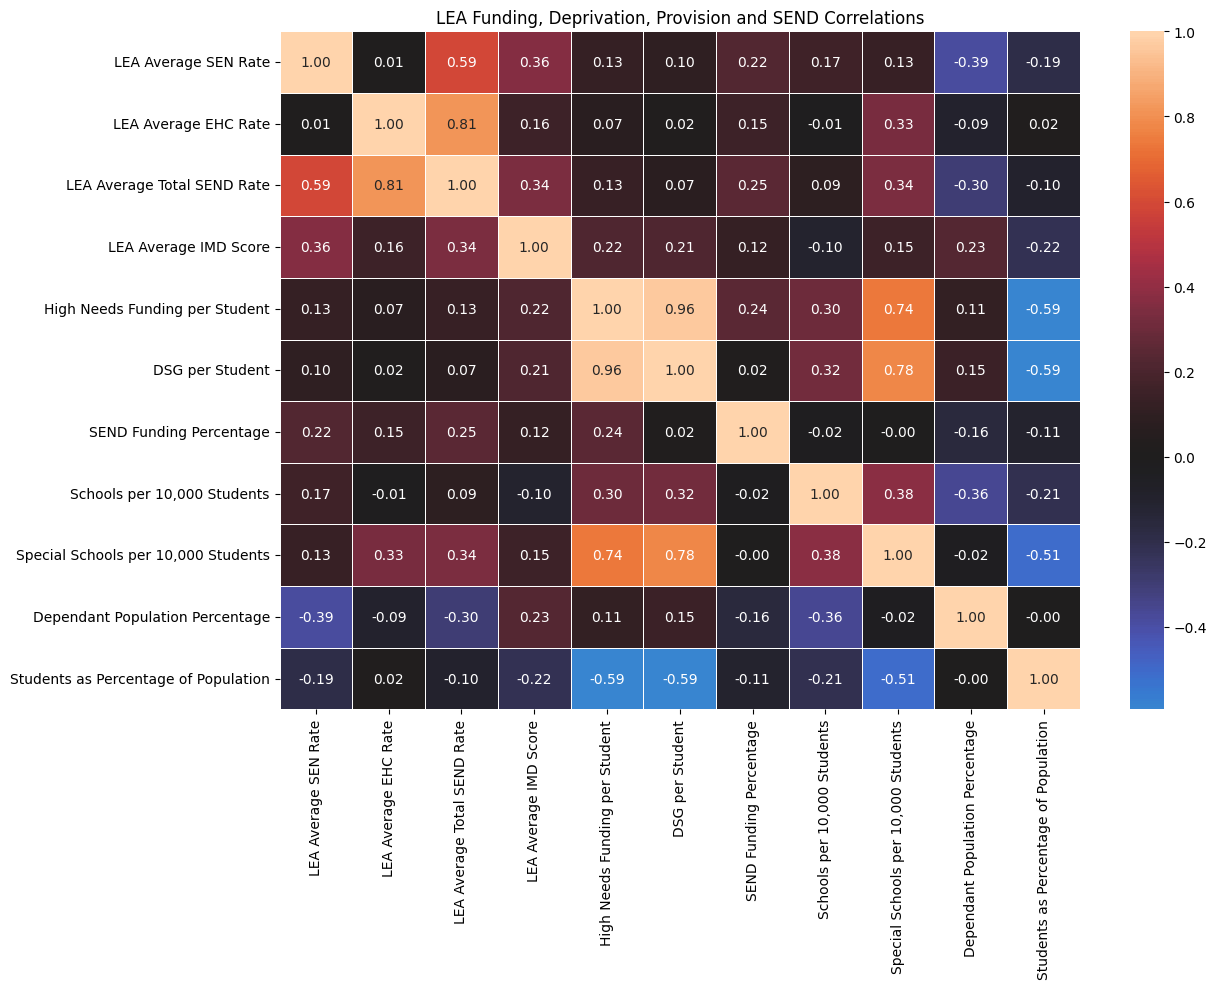

In [ ]:

#Show the initial linear associations between:
#funding measures;
#deprivation;
#school provision;
#SEND outcomes.
#
#This also identifies strongly related funding predictors that may
#produce unstable OLS coefficients.


LEA_FOCUSED_CORRELATION_VARIABLES = [
    "LEA Average SEN Rate",
    "LEA Average EHC Rate",
    "LEA Average Total SEND Rate",
    "LEA Average IMD Score",
    "High Needs Funding per Student",
    "DSG per Student",
    "SEND Funding Percentage",
    "Schools per 10,000 Students",
    "Special Schools per 10,000 Students",
    "Dependant Population Percentage",
    "Students as Percentage of Population"
]

lea_focused_correlation_matrix = (
    lea_regression[
        LEA_FOCUSED_CORRELATION_VARIABLES
    ]
    .corr()
)

plt.figure(
    figsize=(13, 10)
)

sns.heatmap(
    lea_focused_correlation_matrix,
    annot=True,
    fmt=".2f",
    center=0,
    linewidths=0.5
)

plt.title(
    "LEA Funding, Deprivation, Provision and SEND Correlations"
)

plt.tight_layout()
plt.show()

##SECTION 6.22 — DEFINE LEA MACHINE-LEARNING PREDICTORS

In [ ]:

#Use the Model C predictors for Linear, Ridge, Lasso and Random
#Forest regression.

#Region is one-hot encoded.

#Numerical variables are standardised for Linear, Ridge and Lasso.
#Random Forest does not require scaling.


LEA_ML_NUMERIC_PREDICTORS = (
    LEA_MODEL_C_NUMERIC.copy()
)

LEA_ML_CATEGORICAL_PREDICTORS = (
    LEA_MODEL_C_CATEGORICAL.copy()
)

LEA_ML_PREDICTORS = (
    LEA_ML_NUMERIC_PREDICTORS
    +
    LEA_ML_CATEGORICAL_PREDICTORS
)

X_lea = lea_regression[
    LEA_ML_PREDICTORS
].copy()

print(
    "Number of LEA predictors:",
    len(
        LEA_ML_PREDICTORS
    )
)

Number of LEA predictors: 13


##SECTION 6.23 — CREATE LEA TRAIN-TEST SPLITS

In [ ]:

#Divide each LEA outcome into:
#80% training data;
#20% test data.

#The LEA dataset contains only 151 observations, so five-fold
#cross-validation will also be used to reduce reliance on one
#train-test split.


lea_train_test_splits = {}

for outcome in LEA_REGRESSION_OUTCOMES:

    y_lea = (
        lea_regression[outcome]
        .copy()
    )

    (
        X_train,
        X_test,
        y_train,
        y_test
    ) = train_test_split(
        X_lea,
        y_lea,
        test_size=0.20,
        random_state=42
    )

    lea_train_test_splits[
        outcome
    ] = {
        "X_train":
            X_train,

        "X_test":
            X_test,

        "y_train":
            y_train,

        "y_test":
            y_test
    }

    print(
        f"{outcome}: "
        f"{len(X_train)} training LEAs and "
        f"{len(X_test)} test LEAs."
    )

LEA Average SEN Rate: 120 training LEAs and 31 test LEAs.
LEA Average EHC Rate: 120 training LEAs and 31 test LEAs.
LEA Average Total SEND Rate: 120 training LEAs and 31 test LEAs.


##SECTION 6.24 — BUILD LEA PREPROCESSING PIPELINES

In [ ]:

#Apply:
#median imputation to numerical predictors;
#StandardScaler for linear and regularised models;
#one-hot encoding for region;
#no scaling for Random Forest.

#Placing preprocessing inside pipelines prevents information from
#the test data being used during model preparation.


lea_linear_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

lea_tree_numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)

lea_categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="most_frequent"
            )
        ),
        (
            "encoder",
            OneHotEncoder(
                drop="first",
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)

lea_linear_preprocessor = (
    ColumnTransformer(
        transformers=[
            (
                "numeric",
                lea_linear_numeric_pipeline,
                LEA_ML_NUMERIC_PREDICTORS
            ),
            (
                "categorical",
                lea_categorical_pipeline,
                LEA_ML_CATEGORICAL_PREDICTORS
            )
        ],
        remainder="drop"
    )
)

lea_tree_preprocessor = (
    ColumnTransformer(
        transformers=[
            (
                "numeric",
                lea_tree_numeric_pipeline,
                LEA_ML_NUMERIC_PREDICTORS
            ),
            (
                "categorical",
                lea_categorical_pipeline,
                LEA_ML_CATEGORICAL_PREDICTORS
            )
        ],
        remainder="drop"
    )
)

print("LEA preprocessing pipelines created.")

LEA preprocessing pipelines created.


##SECTION 6.25 — DEFINE LEA REGRESSION ALGORITHMS

In [ ]:

#Compare:

#Linear Regression:
#Baseline unregularised linear prediction.

#Ridge:
#StAbilises coefficients where predictors are correlated.

#Lasso:
#Can reduce weaker predictor coefficients to zero.

#Random Forest:
#Captures nonlinear relationships and interactions.


lea_model_templates = {
    "Linear Regression":
        Pipeline(
            steps=[
                (
                    "preprocessor",
                    clone(
                        lea_linear_preprocessor
                    )
                ),
                (
                    "model",
                    LinearRegression()
                )
            ]
        ),

    "Ridge Regression":
        Pipeline(
            steps=[
                (
                    "preprocessor",
                    clone(
                        lea_linear_preprocessor
                    )
                ),
                (
                    "model",
                    Ridge()
                )
            ]
        ),

    "Lasso Regression":
        Pipeline(
            steps=[
                (
                    "preprocessor",
                    clone(
                        lea_linear_preprocessor
                    )
                ),
                (
                    "model",
                    Lasso(
                        max_iter=30000
                    )
                )
            ]
        ),

    "Random Forest":
        Pipeline(
            steps=[
                (
                    "preprocessor",
                    clone(
                        lea_tree_preprocessor
                    )
                ),
                (
                    "model",
                    RandomForestRegressor(
                        random_state=42,
                        n_jobs=-1
                    )
                )
            ]
        )
}

print("LEA regression algorithms defined.")

LEA regression algorithms defined.


##SECTION 6.26 — DEFINE LEA CROSS-VALIDATION

In [ ]:

#Use five-fold cross-validation to estimate how well each model
#generalises across different subsets of the 151 LEAs.


lea_cross_validation = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

LEA_CV_SCORING = {
    "R2":
        "r2",

    "RMSE":
        "neg_root_mean_squared_error",

    "MAE":
        "neg_mean_absolute_error"
}

print("LEA five-fold cross-validation configured.")

LEA five-fold cross-validation configured.


##SECTION 6.27 — TUNE LEA RIDGE REGRESSION

In [ ]:

#Select the Ridge alpha that gives the strongest average training
#cross-validation R-squared.

#Larger alpha values apply stronger coefficient shrinkage.


LEA_RIDGE_PARAMETER_GRID = {
    "model__alpha": [
        0.001,
        0.01,
        0.1,
        1,
        10,
        100,
        1000
    ]
}

best_lea_ridge_models = {}
lea_ridge_tuning_rows = []

for outcome in LEA_REGRESSION_OUTCOMES:

    split = (
        lea_train_test_splits[
            outcome
        ]
    )

    search = GridSearchCV(
        estimator=clone(
            lea_model_templates[
                "Ridge Regression"
            ]
        ),
        param_grid=(
            LEA_RIDGE_PARAMETER_GRID
        ),
        scoring="r2",
        cv=lea_cross_validation,
        n_jobs=-1
    )

    search.fit(
        split["X_train"],
        split["y_train"]
    )

    best_lea_ridge_models[
        outcome
    ] = (
        search.best_estimator_
    )

    lea_ridge_tuning_rows.append({
        "Outcome":
            outcome,

        "Best Alpha":
            search.best_params_[
                "model__alpha"
            ],

        "Best Mean CV R-squared":
            search.best_score_
    })

lea_ridge_tuning_table = pd.DataFrame(
    lea_ridge_tuning_rows
)

display(
    lea_ridge_tuning_table.round(5)
)

,Outcome,Best Alpha,Best Mean CV R-squared
0,LEA Average SEN Rate,1.0000,0.3031
1,LEA Average EHC Rate,1.0000,0.2198
2,LEA Average Total SEND Rate,0.1000,0.4013


##SECTION 6.28 — TUNE LEA LASSO REGRESSION

In [ ]:

#Select the Lasso alpha that balances prediction and variable
#selection.

#Small values are included because SEND rates are proportions and
#the LEA sample is relatively small.


LEA_LASSO_PARAMETER_GRID = {
    "model__alpha": [
        0.000001,
        0.000005,
        0.00001,
        0.00005,
        0.0001,
        0.0005,
        0.001,
        0.005,
        0.01
    ]
}

best_lea_lasso_models = {}
lea_lasso_tuning_rows = []

for outcome in LEA_REGRESSION_OUTCOMES:

    split = (
        lea_train_test_splits[
            outcome
        ]
    )

    search = GridSearchCV(
        estimator=clone(
            lea_model_templates[
                "Lasso Regression"
            ]
        ),
        param_grid=(
            LEA_LASSO_PARAMETER_GRID
        ),
        scoring="r2",
        cv=lea_cross_validation,
        n_jobs=-1
    )

    search.fit(
        split["X_train"],
        split["y_train"]
    )

    best_lea_lasso_models[
        outcome
    ] = (
        search.best_estimator_
    )

    lea_lasso_tuning_rows.append({
        "Outcome":
            outcome,

        "Best Alpha":
            search.best_params_[
                "model__alpha"
            ],

        "Best Mean CV R-squared":
            search.best_score_
    })

lea_lasso_tuning_table = pd.DataFrame(
    lea_lasso_tuning_rows
)

display(
    lea_lasso_tuning_table.round(6)
)

,Outcome,Best Alpha,Best Mean CV R-squared
0,LEA Average SEN Rate,0.0001,0.3068
1,LEA Average EHC Rate,0.0001,0.2088
2,LEA Average Total SEND Rate,0.0001,0.3924


##SECTION 6.29 — TUNE LEA RANDOM FOREST

In [ ]:


LEA_RF_PARAMETER_GRID = {
    "model__n_estimators": [
        200,
        400
    ],

    "model__max_depth": [
        None,
        3,
        5,
        7
    ],

    "model__min_samples_leaf": [
        2,
        4,
        6
    ]
}

best_lea_random_forest_models = {}
lea_rf_tuning_rows = []

for outcome in LEA_REGRESSION_OUTCOMES:

    split = (
        lea_train_test_splits[
            outcome
        ]
    )

    search = GridSearchCV(
        estimator=clone(
            lea_model_templates[
                "Random Forest"
            ]
        ),
        param_grid=(
            LEA_RF_PARAMETER_GRID
        ),
        scoring="r2",
        cv=lea_cross_validation,
        n_jobs=-1
    )

    search.fit(
        split["X_train"],
        split["y_train"]
    )

    best_lea_random_forest_models[
        outcome
    ] = (
        search.best_estimator_
    )

    lea_rf_tuning_rows.append({
        "Outcome":
            outcome,

        "Best Parameters":
            search.best_params_,

        "Best Mean CV R-squared":
            search.best_score_
    })

lea_rf_tuning_table = pd.DataFrame(
    lea_rf_tuning_rows
)

display(
    lea_rf_tuning_table
)

,Outcome,Best Parameters,Best Mean CV R-squared
0,LEA Average SEN Rate,"{'model__max_depth': None, 'model__min_samples...",0.1538
1,LEA Average EHC Rate,"{'model__max_depth': 7, 'model__min_samples_le...",0.2582
2,LEA Average Total SEND Rate,"{'model__max_depth': 7, 'model__min_samples_le...",0.2402


##SECTION 6.30 — FIT AND EVALUATE LEA MODELS

In [ ]:

#Fit the four modelling approaches and evaluate:
#training R-squared;
#test R-squared;
#test RMSE;
#test MAE;
#the training-test R-squared gap.

#A large positive training-test gap suggests overfitting.


def lea_regression_metrics(
    actual,
    predicted
):
    """
    Calculate LEA regression performance measures.
    """

    return {
        "R-squared":
            r2_score(
                actual,
                predicted
            ),

        "RMSE":
            np.sqrt(
                mean_squared_error(
                    actual,
                    predicted
                )
            ),

        "MAE":
            mean_absolute_error(
                actual,
                predicted
            )
    }


fitted_lea_ml_models = {}
lea_model_evaluation_rows = []

for outcome in LEA_REGRESSION_OUTCOMES:

    split = (
        lea_train_test_splits[
            outcome
        ]
    )

    candidate_models = {
        "Linear Regression":
            clone(
                lea_model_templates[
                    "Linear Regression"
                ]
            ),

        "Ridge Regression":
            clone(
                best_lea_ridge_models[
                    outcome
                ]
            ),

        "Lasso Regression":
            clone(
                best_lea_lasso_models[
                    outcome
                ]
            ),

        "Random Forest":
            clone(
                best_lea_random_forest_models[
                    outcome
                ]
            )
    }

    fitted_lea_ml_models[
        outcome
    ] = {}

    for model_name, model in (
        candidate_models.items()
    ):

        model.fit(
            split["X_train"],
            split["y_train"]
        )

        fitted_lea_ml_models[
            outcome
        ][model_name] = model

        train_prediction = model.predict(
            split["X_train"]
        )

        test_prediction = model.predict(
            split["X_test"]
        )

        train_metrics = (
            lea_regression_metrics(
                split["y_train"],
                train_prediction
            )
        )

        test_metrics = (
            lea_regression_metrics(
                split["y_test"],
                test_prediction
            )
        )

        lea_model_evaluation_rows.append({
            "Outcome":
                outcome,

            "Model":
                model_name,

            "Training R-squared":
                train_metrics[
                    "R-squared"
                ],

            "Test R-squared":
                test_metrics[
                    "R-squared"
                ],

            "Test RMSE":
                test_metrics[
                    "RMSE"
                ],

            "Test MAE":
                test_metrics[
                    "MAE"
                ],

            "Training-Test R-squared Gap":
                (
                    train_metrics[
                        "R-squared"
                    ]
                    -
                    test_metrics[
                        "R-squared"
                    ]
                )
        })

lea_model_evaluation_table = (
    pd.DataFrame(
        lea_model_evaluation_rows
    )
)

display(
    lea_model_evaluation_table.round(4)
)

,Outcome,Model,Training R-squared,Test R-squared,Test RMSE,Test MAE,Training-Test R-squared Gap
0,LEA Average SEN Rate,Linear Regression,0.5436,0.2532,0.0153,0.0108,0.2904
1,LEA Average SEN Rate,Ridge Regression,0.5371,0.3018,0.0148,0.0104,0.2353
2,LEA Average SEN Rate,Lasso Regression,0.5336,0.3042,0.0148,0.0104,0.2294
3,LEA Average SEN Rate,Random Forest,0.8653,0.3703,0.0141,0.0107,0.4951
4,LEA Average EHC Rate,Linear Regression,0.4946,0.0034,0.0230,0.0166,0.4912
5,LEA Average EHC Rate,Ridge Regression,0.4652,0.1354,0.0214,0.0154,0.3299
6,LEA Average EHC Rate,Lasso Regression,0.4647,0.1089,0.0217,0.0154,0.3558
7,LEA Average EHC Rate,Random Forest,0.8426,0.1100,0.0217,0.0165,0.7326
8,LEA Average Total SEND Rate,Linear Regression,0.6434,0.3815,0.0220,0.0168,0.2619
9,LEA Average Total SEND Rate,Ridge Regression,0.6423,0.4084,0.0216,0.0164,0.2339


##SECTION 6.31 — RUN LEA FIVE-FOLD CROSS-VALIDATION

In [ ]:

#Assess model stability across repeated training and validation
#subsets.

#Mean CV R-squared is the primary predictive comparison measure.

#NegaTive CV R-squared means the model predicts worse than simply
#using the outcome mean in the validation folds.


lea_cross_validation_rows = []

for outcome in LEA_REGRESSION_OUTCOMES:

    split = (
        lea_train_test_splits[
            outcome
        ]
    )

    for model_name, fitted_model in (
        fitted_lea_ml_models[
            outcome
        ].items()
    ):

        cv_results = cross_validate(
            estimator=clone(
                fitted_model
            ),
            X=split["X_train"],
            y=split["y_train"],
            cv=lea_cross_validation,
            scoring=LEA_CV_SCORING,
            n_jobs=-1
        )

        lea_cross_validation_rows.append({
            "Outcome":
                outcome,

            "Model":
                model_name,

            "Mean CV R-squared":
                np.mean(
                    cv_results[
                        "test_R2"
                    ]
                ),

            "CV R-squared Standard Deviation":
                np.std(
                    cv_results[
                        "test_R2"
                    ]
                ),

            "Mean CV RMSE":
                -np.mean(
                    cv_results[
                        "test_RMSE"
                    ]
                ),

            "Mean CV MAE":
                -np.mean(
                    cv_results[
                        "test_MAE"
                    ]
                )
        })

lea_cross_validation_table = (
    pd.DataFrame(
        lea_cross_validation_rows
    )
)

display(
    lea_cross_validation_table.round(4)
)

,Outcome,Model,Mean CV R-squared,CV R-squared Standard Deviation,Mean CV RMSE,Mean CV MAE
0,LEA Average SEN Rate,Linear Regression,0.2853,0.0933,0.0142,0.0111
1,LEA Average SEN Rate,Ridge Regression,0.3031,0.0776,0.0141,0.0109
2,LEA Average SEN Rate,Lasso Regression,0.3068,0.0825,0.0140,0.0109
3,LEA Average SEN Rate,Random Forest,0.1538,0.0955,0.0156,0.0123
4,LEA Average EHC Rate,Linear Regression,0.1836,0.1555,0.0222,0.0177
5,LEA Average EHC Rate,Ridge Regression,0.2198,0.1554,0.0218,0.0172
6,LEA Average EHC Rate,Lasso Regression,0.2088,0.1548,0.0219,0.0174
7,LEA Average EHC Rate,Random Forest,0.2582,0.0874,0.0214,0.0171
8,LEA Average Total SEND Rate,Linear Regression,0.3862,0.1279,0.0233,0.0181
9,LEA Average Total SEND Rate,Ridge Regression,0.4013,0.1296,0.0230,0.0179


##SECTION 6.32 — CREATE FINAL LEA MODEL COMPARISON

In [ ]:

#Combine test-set and cross-validation results.

#The preferred predictive model should be selected using:
#mean CV R-squared;
#test R-squared;
#RMSE;
#MAE;
#evidence of overfitting;
#interpretability.


lea_final_model_comparison = (
    lea_model_evaluation_table
    .merge(
        lea_cross_validation_table,
        on=[
            "Outcome",
            "Model"
        ],
        how="left"
    )
    .sort_values(
        [
            "Outcome",
            "Mean CV R-squared"
        ],
        ascending=[
            True,
            False
        ]
    )
)

display(
    lea_final_model_comparison[
        [
            "Outcome",
            "Model",
            "Training R-squared",
            "Test R-squared",
            "Mean CV R-squared",
            "CV R-squared Standard Deviation",
            "Test RMSE",
            "Mean CV RMSE",
            "Test MAE",
            "Mean CV MAE",
            "Training-Test R-squared Gap"
        ]
    ].round(4)
)

,Outcome,Model,Training R-squared,Test R-squared,Mean CV R-squared,CV R-squared Standard Deviation,Test RMSE,Mean CV RMSE,Test MAE,Mean CV MAE,Training-Test R-squared Gap
7,LEA Average EHC Rate,Random Forest,0.8426,0.1100,0.2582,0.0874,0.0217,0.0214,0.0165,0.0171,0.7326
5,LEA Average EHC Rate,Ridge Regression,0.4652,0.1354,0.2198,0.1554,0.0214,0.0218,0.0154,0.0172,0.3299
6,LEA Average EHC Rate,Lasso Regression,0.4647,0.1089,0.2088,0.1548,0.0217,0.0219,0.0154,0.0174,0.3558
4,LEA Average EHC Rate,Linear Regression,0.4946,0.0034,0.1836,0.1555,0.0230,0.0222,0.0166,0.0177,0.4912
2,LEA Average SEN Rate,Lasso Regression,0.5336,0.3042,0.3068,0.0825,0.0148,0.0140,0.0104,0.0109,0.2294
1,LEA Average SEN Rate,Ridge Regression,0.5371,0.3018,0.3031,0.0776,0.0148,0.0141,0.0104,0.0109,0.2353
0,LEA Average SEN Rate,Linear Regression,0.5436,0.2532,0.2853,0.0933,0.0153,0.0142,0.0108,0.0111,0.2904
3,LEA Average SEN Rate,Random Forest,0.8653,0.3703,0.1538,0.0955,0.0141,0.0156,0.0107,0.0123,0.4951
9,LEA Average Total SEND Rate,Ridge Regression,0.6423,0.4084,0.4013,0.1296,0.0216,0.0230,0.0164,0.0179,0.2339
10,LEA Average Total SEND Rate,Lasso Regression,0.6379,0.4341,0.3924,0.1265,0.0211,0.0232,0.0160,0.0181,0.2038


##SECTION 6.33 — IDENTIFY THE PREFERRED LEA MODEL

In [ ]:

#Select the model with the highest mean cross-validation R-squared
#for each LEA SEND outcome.

#This is the preferred predictive model.

#Model C OLS remains the primary explanatory model because it
#provides coefficients, p-values and confidence intervals.


preferred_lea_model_rows = []

for outcome in LEA_REGRESSION_OUTCOMES:

    outcome_results = (
        lea_final_model_comparison[
            lea_final_model_comparison[
                "Outcome"
            ] == outcome
        ]
        .sort_values(
            "Mean CV R-squared",
            ascending=False
        )
    )

    preferred_lea_model_rows.append(
        outcome_results.iloc[0]
    )

preferred_lea_models_table = (
    pd.DataFrame(
        preferred_lea_model_rows
    )
    .reset_index(
        drop=True
    )
)

display(
    preferred_lea_models_table[
        [
            "Outcome",
            "Model",
            "Test R-squared",
            "Mean CV R-squared",
            "Test RMSE",
            "Test MAE"
        ]
    ].round(4)
)

,Outcome,Model,Test R-squared,Mean CV R-squared,Test RMSE,Test MAE
0,LEA Average SEN Rate,Lasso Regression,0.3042,0.3068,0.0148,0.0104
1,LEA Average EHC Rate,Random Forest,0.1100,0.2582,0.0217,0.0165
2,LEA Average Total SEND Rate,Ridge Regression,0.4084,0.4013,0.0216,0.0164


##SECTION 6.34 — PLOT LEA MODEL PERFORMANCE

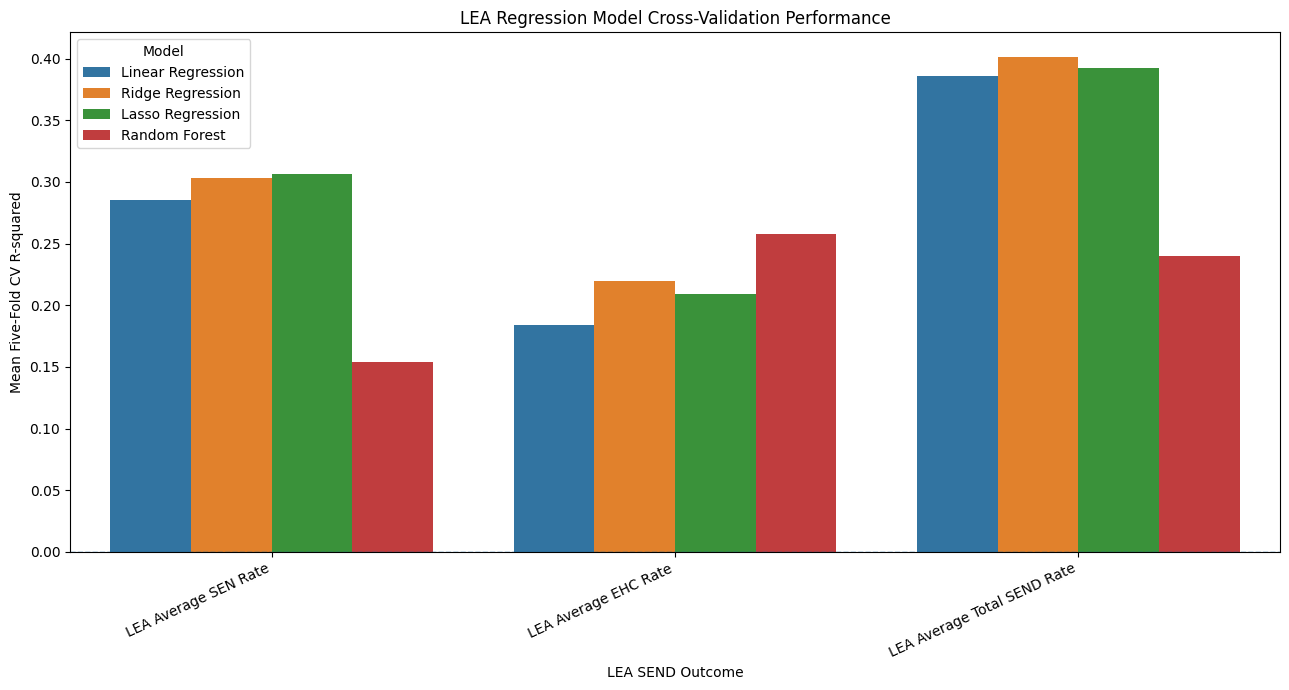

In [ ]:

#Compare the mean five-fold cross-validation R-squared of Linear,
#Ridge, Lasso and Random Forest models.


plt.figure(
    figsize=(13, 7)
)

sns.barplot(
    data=lea_cross_validation_table,
    x="Outcome",
    y="Mean CV R-squared",
    hue="Model"
)

plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)

plt.title(
    "LEA Regression Model Cross-Validation Performance"
)

plt.xlabel(
    "LEA SEND Outcome"
)

plt.ylabel(
    "Mean Five-Fold CV R-squared"
)

plt.xticks(
    rotation=25,
    ha="right"
)

plt.tight_layout()
plt.show()

##SECTION 6.35 — PLOT ACTUAL VERSUS PREDICTED LEA VALUES

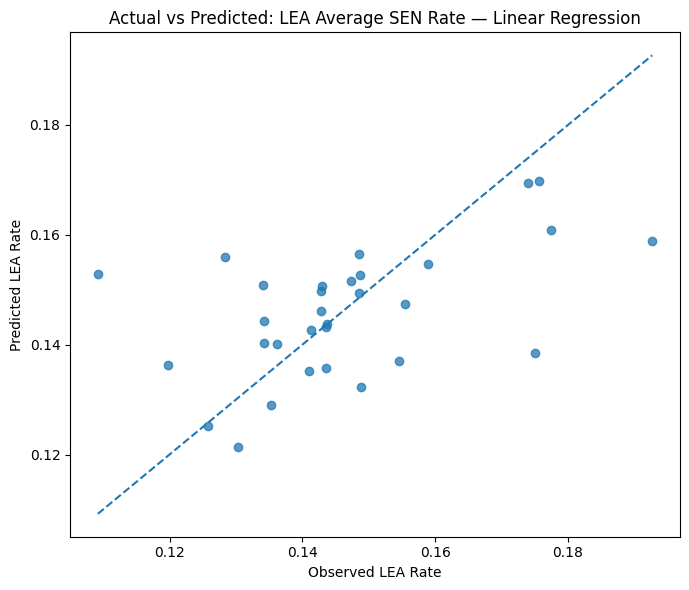

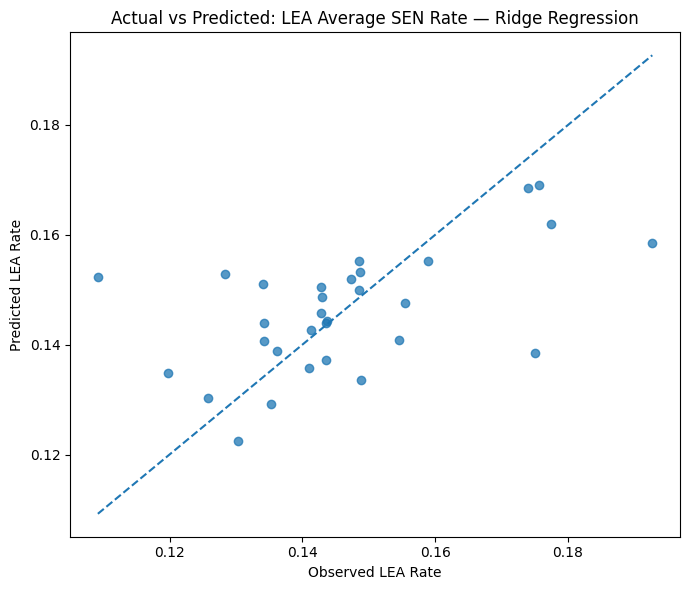

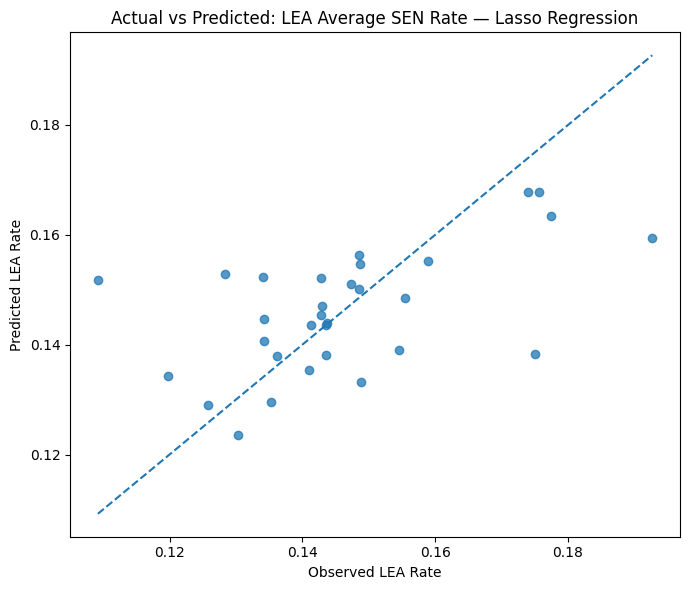

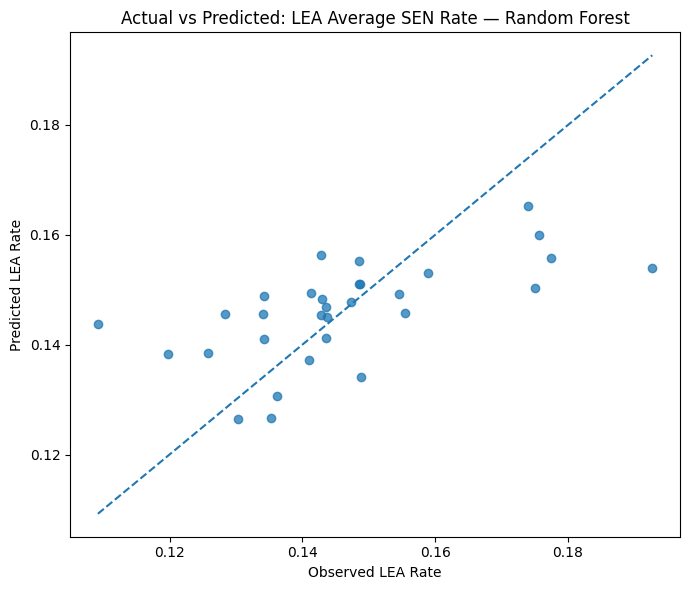

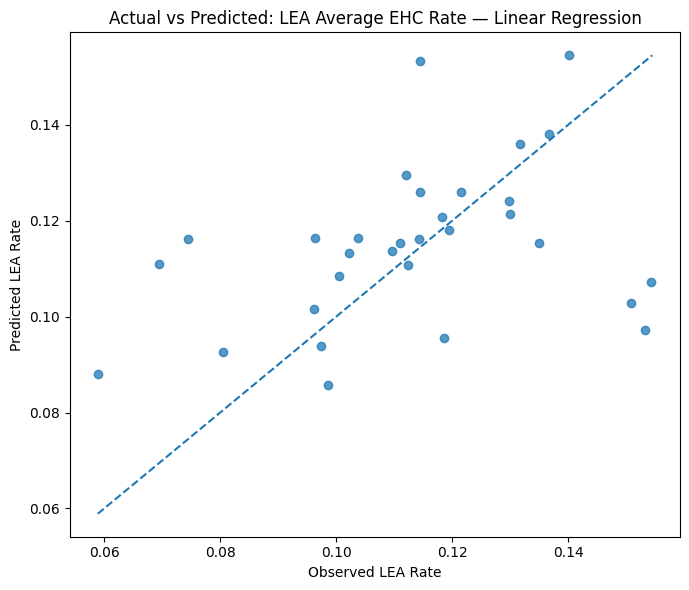

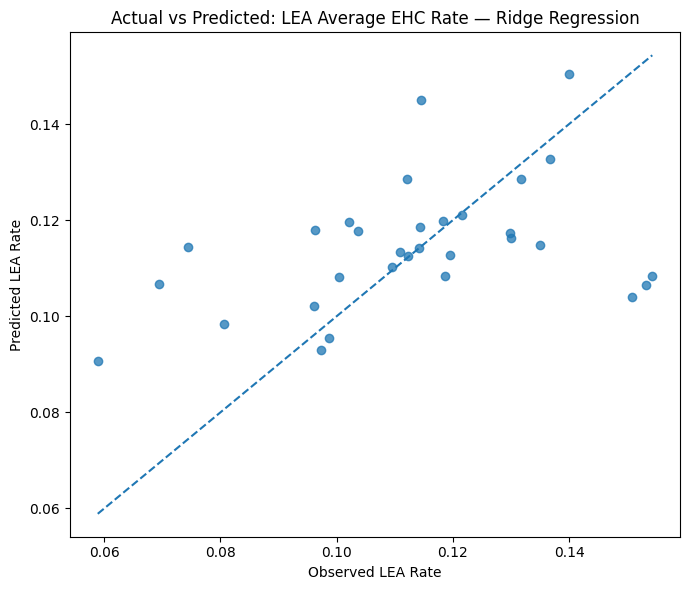

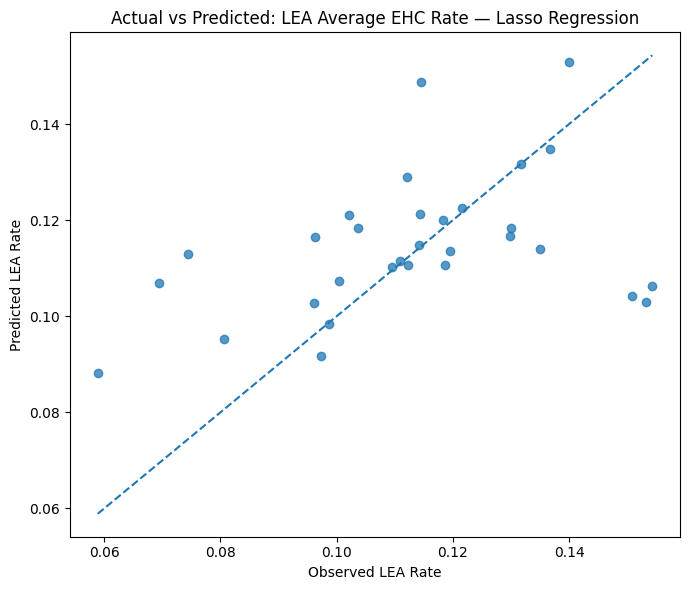

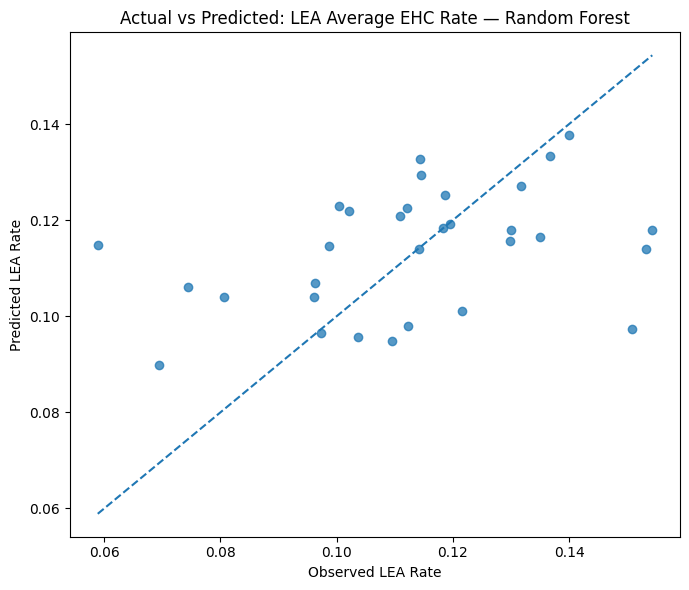

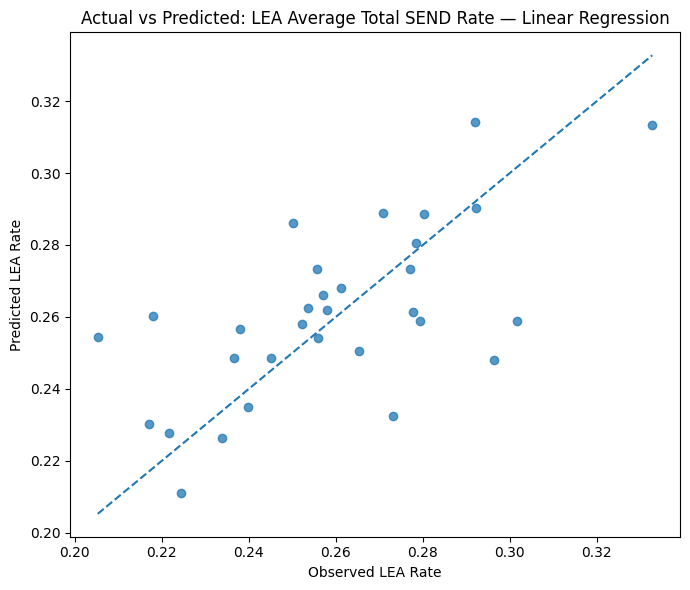

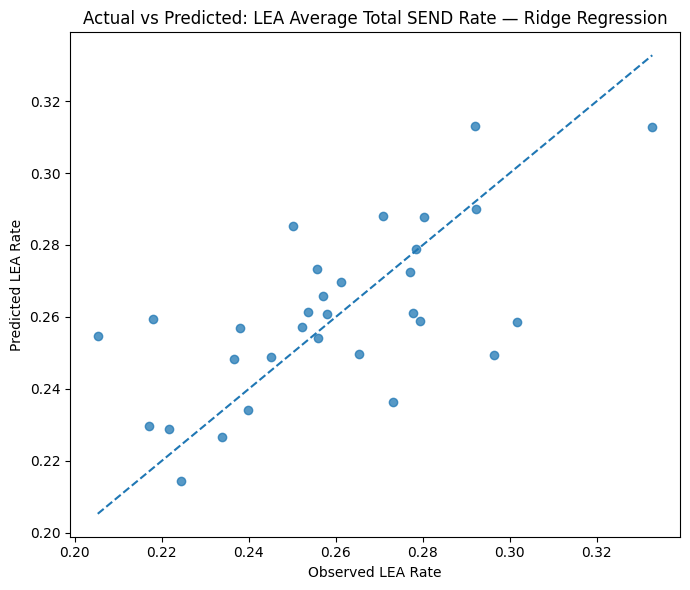

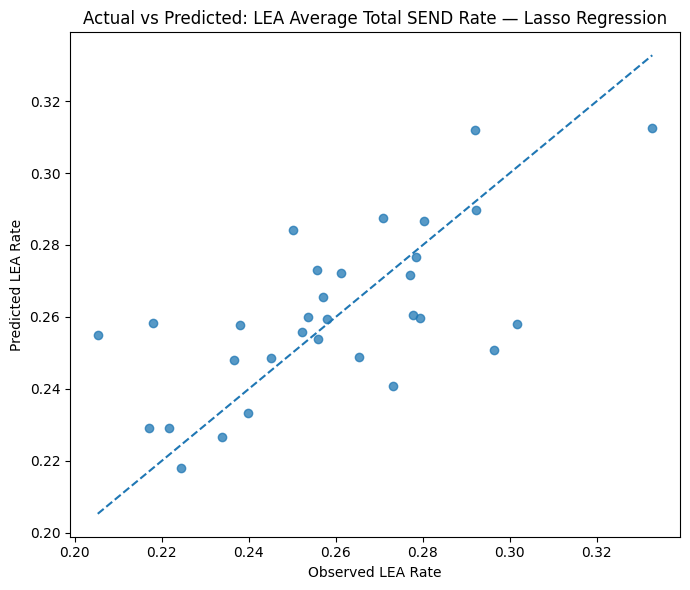

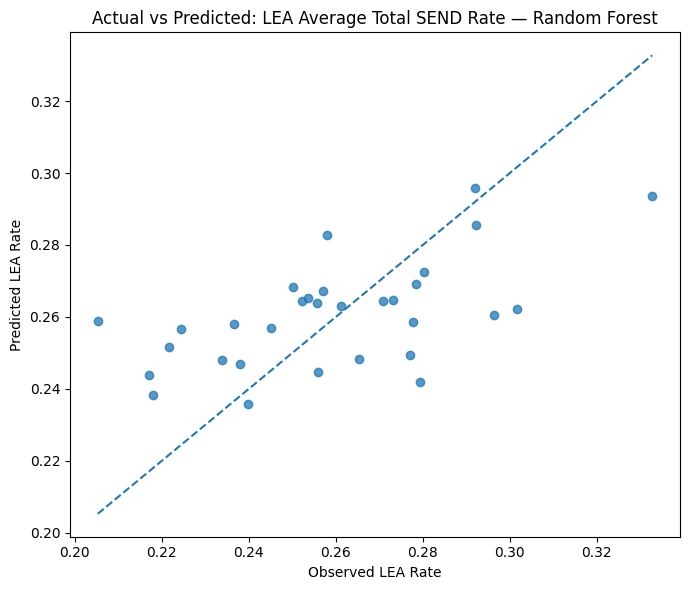

In [ ]:

#Show how closely each model's test predictions match the observed
#LEA SEND rates.

#Points close to the diagonal reference line represent more
#accurate predictions.


for outcome in LEA_REGRESSION_OUTCOMES:

    split = (
        lea_train_test_splits[
            outcome
        ]
    )

    for model_name, fitted_model in (
        fitted_lea_ml_models[
            outcome
        ].items()
    ):

        predictions = (
            fitted_model.predict(
                split["X_test"]
            )
        )

        minimum_value = min(
            split["y_test"].min(),
            predictions.min()
        )

        maximum_value = max(
            split["y_test"].max(),
            predictions.max()
        )

        plt.figure(
            figsize=(7, 6)
        )

        plt.scatter(
            split["y_test"],
            predictions,
            alpha=0.75
        )

        plt.plot(
            [
                minimum_value,
                maximum_value
            ],
            [
                minimum_value,
                maximum_value
            ],
            linestyle="--"
        )

        plt.title(
            f"Actual vs Predicted: "
            f"{outcome} — {model_name}"
        )

        plt.xlabel(
            "Observed LEA Rate"
        )

        plt.ylabel(
            "Predicted LEA Rate"
        )

        plt.tight_layout()
        plt.show()

##SECTION 6.36 — EXTRACT TRANSFORMED LEA FEATURE NAMES

In [ ]:

#Match Ridge and Lasso coefficients to their numerical and encoded
#regional predictor names.


def get_lea_feature_names(
    fitted_pipeline
):
    """
    Retrieve cleaned transformed feature names.
    """

    preprocessor = (
        fitted_pipeline.named_steps[
            "preprocessor"
        ]
    )

    transformed_names = (
        preprocessor
        .get_feature_names_out()
        .tolist()
    )

    return [
        name
        .replace(
            "numeric__",
            ""
        )
        .replace(
            "categorical__",
            ""
        )

        for name in transformed_names
    ]

##SECTION 6.37 — EXTRACT LEA RIDGE COEFFICIENTS

In [ ]:

#Identify the direction and relative magnitude of stabilised Ridge
#coefficients.
#
#Numerical predictors are standardised, making their coefficient
#magnitudes more comparable.


lea_ridge_coefficient_tables = {}

for outcome in LEA_REGRESSION_OUTCOMES:

    fitted_model = (
        fitted_lea_ml_models[
            outcome
        ]["Ridge Regression"]
    )

    feature_names = (
        get_lea_feature_names(
            fitted_model
        )
    )

    coefficients = (
        fitted_model.named_steps[
            "model"
        ].coef_
    )

    coefficient_table = pd.DataFrame({
        "Feature":
            feature_names,

        "Coefficient":
            coefficients
    })

    coefficient_table[
        "Absolute Coefficient"
    ] = (
        coefficient_table[
            "Coefficient"
        ].abs()
    )

    coefficient_table = (
        coefficient_table.sort_values(
            "Absolute Coefficient",
            ascending=False
        )
    )

    lea_ridge_coefficient_tables[
        outcome
    ] = coefficient_table

    print("=" * 90)
    print(
        f"LEA RIDGE COEFFICIENTS: {outcome}"
    )
    print("=" * 90)

    display(
        coefficient_table.head(20)
        .round(6)
    )

LEA RIDGE COEFFICIENTS: LEA Average SEN Rate


,Feature,Coefficient,Absolute Coefficient
4,LEA Average Employment Score,0.0141,0.0141
16,geo-Political Zone_South East,0.0104,0.0104
12,geo-Political Zone_East of England,0.0102,0.0102
17,geo-Political Zone_South West,0.0099,0.0099
18,geo-Political Zone_West Midlands,0.0097,0.0097
7,Dependant Population Percentage,-0.0067,0.0067
5,"LEA Average Education, Skills and Training Score",-0.0060,0.0060
0,LEA Average IMD Score,0.0057,0.0057
15,geo-Political Zone_North West,-0.0052,0.0052
13,geo-Political Zone_London,-0.0042,0.0042


LEA RIDGE COEFFICIENTS: LEA Average EHC Rate


,Feature,Coefficient,Absolute Coefficient
15,geo-Political Zone_North West,0.0220,0.0220
13,geo-Political Zone_London,0.0213,0.0213
4,LEA Average Employment Score,0.0212,0.0212
0,LEA Average IMD Score,-0.0210,0.0210
10,"Special Schools per 10,000 Students",0.0163,0.0163
18,geo-Political Zone_West Midlands,0.0112,0.0112
6,LEA Average Income Deprivation Affecting Child...,0.0088,0.0088
3,LEA Average Income Score Rate,-0.0083,0.0083
16,geo-Political Zone_South East,0.0079,0.0079
8,Students as Percentage of Population,0.0065,0.0065


LEA RIDGE COEFFICIENTS: LEA Average Total SEND Rate


,Feature,Coefficient,Absolute Coefficient
4,LEA Average Employment Score,0.0458,0.0458
13,geo-Political Zone_London,0.0383,0.0383
18,geo-Political Zone_West Midlands,0.0354,0.0354
16,geo-Political Zone_South East,0.0340,0.0340
15,geo-Political Zone_North West,0.0334,0.0334
12,geo-Political Zone_East of England,0.0298,0.0298
0,LEA Average IMD Score,-0.0272,0.0272
17,geo-Political Zone_South West,0.0269,0.0269
3,LEA Average Income Score Rate,-0.0253,0.0253
6,LEA Average Income Deprivation Affecting Child...,0.0191,0.0191


##SECTION 6.38 — EXTRACT LEA LASSO-SELECTED PREDICTORS

In [ ]:

#Identify predictors whose Lasso coefficients remain non-zero.

#A predictor reduced to zero adds limited predictive value under
#the selected penalty once the other predictors are included.


lea_lasso_coefficient_tables = {}

for outcome in LEA_REGRESSION_OUTCOMES:

    fitted_model = (
        fitted_lea_ml_models[
            outcome
        ]["Lasso Regression"]
    )

    feature_names = (
        get_lea_feature_names(
            fitted_model
        )
    )

    coefficients = (
        fitted_model.named_steps[
            "model"
        ].coef_
    )

    coefficient_table = pd.DataFrame({
        "Feature":
            feature_names,

        "Coefficient":
            coefficients
    })

    coefficient_table[
        "Retained by Lasso"
    ] = (
        coefficient_table[
            "Coefficient"
        ].abs() > 1e-10
    )

    coefficient_table[
        "Absolute Coefficient"
    ] = (
        coefficient_table[
            "Coefficient"
        ].abs()
    )

    coefficient_table = (
        coefficient_table.sort_values(
            "Absolute Coefficient",
            ascending=False
        )
    )

    lea_lasso_coefficient_tables[
        outcome
    ] = coefficient_table

    print("=" * 90)
    print(
        f"LEA LASSO COEFFICIENTS: {outcome}"
    )
    print("=" * 90)

    display(
        coefficient_table[
            coefficient_table[
                "Retained by Lasso"
            ]
        ].round(6)
    )

    print(
        "Number of retained predictors:",
        coefficient_table[
            "Retained by Lasso"
        ].sum()
    )

LEA LASSO COEFFICIENTS: LEA Average SEN Rate


,Feature,Coefficient,Retained by Lasso,Absolute Coefficient
4,LEA Average Employment Score,0.0153,True,0.0153
16,geo-Political Zone_South East,0.0129,True,0.0129
12,geo-Political Zone_East of England,0.0123,True,0.0123
17,geo-Political Zone_South West,0.0119,True,0.0119
18,geo-Political Zone_West Midlands,0.0114,True,0.0114
7,Dependant Population Percentage,-0.0075,True,0.0075
5,"LEA Average Education, Skills and Training Score",-0.0040,True,0.0040
2,SEND Funding Percentage,0.0016,True,0.0016
15,geo-Political Zone_North West,-0.0012,True,0.0012
3,LEA Average Income Score Rate,-0.0012,True,0.0012


Number of retained predictors: 18
LEA LASSO COEFFICIENTS: LEA Average EHC Rate


,Feature,Coefficient,Retained by Lasso,Absolute Coefficient
0,LEA Average IMD Score,-0.0306,True,0.0306
4,LEA Average Employment Score,0.0248,True,0.0248
15,geo-Political Zone_North West,0.0214,True,0.0214
13,geo-Political Zone_London,0.0207,True,0.0207
10,"Special Schools per 10,000 Students",0.0161,True,0.0161
18,geo-Political Zone_West Midlands,0.0089,True,0.0089
5,"LEA Average Education, Skills and Training Score",0.0074,True,0.0074
16,geo-Political Zone_South East,0.0066,True,0.0066
8,Students as Percentage of Population,0.0066,True,0.0066
1,High Needs Funding per Student,-0.0059,True,0.0059


Number of retained predictors: 17
LEA LASSO COEFFICIENTS: LEA Average Total SEND Rate


,Feature,Coefficient,Retained by Lasso,Absolute Coefficient
4,LEA Average Employment Score,0.0447,True,0.0447
13,geo-Political Zone_London,0.0315,True,0.0315
18,geo-Political Zone_West Midlands,0.0306,True,0.0306
16,geo-Political Zone_South East,0.0294,True,0.0294
15,geo-Political Zone_North West,0.0274,True,0.0274
0,LEA Average IMD Score,-0.0254,True,0.0254
12,geo-Political Zone_East of England,0.0252,True,0.0252
17,geo-Political Zone_South West,0.0220,True,0.0220
3,LEA Average Income Score Rate,-0.0199,True,0.0199
6,LEA Average Income Deprivation Affecting Child...,0.0146,True,0.0146


Number of retained predictors: 20


##SECTION 6.39 — CALCULATE LEA RANDOM FOREST IMPORTANCE

In [ ]:

#Measure how much test-set R-squared declines when each original
#predictor is randomly rearranged.

#A larger positive value indicates greater predictive importance.

#Near-zero or negative importance suggests limited contribution to
#test prediction.


lea_random_forest_importance_tables = {}

for outcome in LEA_REGRESSION_OUTCOMES:

    split = (
        lea_train_test_splits[
            outcome
        ]
    )

    fitted_model = (
        fitted_lea_ml_models[
            outcome
        ]["Random Forest"]
    )

    result = permutation_importance(
        estimator=fitted_model,
        X=split["X_test"],
        y=split["y_test"],
        scoring="r2",
        n_repeats=30,
        random_state=42,
        n_jobs=-1
    )

    importance_table = pd.DataFrame({
        "Predictor":
            split["X_test"].columns,

        "Mean Permutation Importance":
            result.importances_mean,

        "Importance Standard Deviation":
            result.importances_std
    })

    importance_table = (
        importance_table.sort_values(
            "Mean Permutation Importance",
            ascending=False
        )
    )

    lea_random_forest_importance_tables[
        outcome
    ] = importance_table

    print("=" * 90)
    print(
        f"LEA RANDOM FOREST IMPORTANCE: {outcome}"
    )
    print("=" * 90)

    display(
        importance_table.round(6)
    )

LEA RANDOM FOREST IMPORTANCE: LEA Average SEN Rate


,Predictor,Mean Permutation Importance,Importance Standard Deviation
7,Dependant Population Percentage,0.2497,0.1138
4,LEA Average Employment Score,0.1781,0.0569
0,LEA Average IMD Score,0.0944,0.0385
9,"Schools per 10,000 Students",0.0286,0.0170
8,Students as Percentage of Population,0.0233,0.0070
1,High Needs Funding per Student,0.0225,0.0071
2,SEND Funding Percentage,0.0133,0.0123
6,LEA Average Income Deprivation Affecting Child...,0.0111,0.0090
5,"LEA Average Education, Skills and Training Score",0.0013,0.0127
11,Number of LAs Under LEA,0.0007,0.0029


LEA RANDOM FOREST IMPORTANCE: LEA Average EHC Rate


,Predictor,Mean Permutation Importance,Importance Standard Deviation
10,"Special Schools per 10,000 Students",0.5010,0.1330
1,High Needs Funding per Student,0.0867,0.0420
8,Students as Percentage of Population,0.0710,0.0262
7,Dependant Population Percentage,0.0230,0.0164
3,LEA Average Income Score Rate,0.0121,0.0085
6,LEA Average Income Deprivation Affecting Child...,0.0109,0.0079
12,geo-Political Zone,0.0079,0.0205
11,Number of LAs Under LEA,0.0010,0.0011
0,LEA Average IMD Score,-0.0026,0.0056
4,LEA Average Employment Score,-0.0039,0.0187


LEA RANDOM FOREST IMPORTANCE: LEA Average Total SEND Rate


,Predictor,Mean Permutation Importance,Importance Standard Deviation
10,"Special Schools per 10,000 Students",0.2813,0.1095
7,Dependant Population Percentage,0.1772,0.0746
4,LEA Average Employment Score,0.1075,0.0691
2,SEND Funding Percentage,0.0722,0.0926
6,LEA Average Income Deprivation Affecting Child...,0.0197,0.0136
8,Students as Percentage of Population,0.0122,0.0108
0,LEA Average IMD Score,0.0118,0.0083
12,geo-Political Zone,0.0059,0.0104
9,"Schools per 10,000 Students",0.0051,0.0122
1,High Needs Funding per Student,0.0030,0.0064


##SECTION 6.40 — PLOT LEA RANDOM FOREST IMPORTANCE

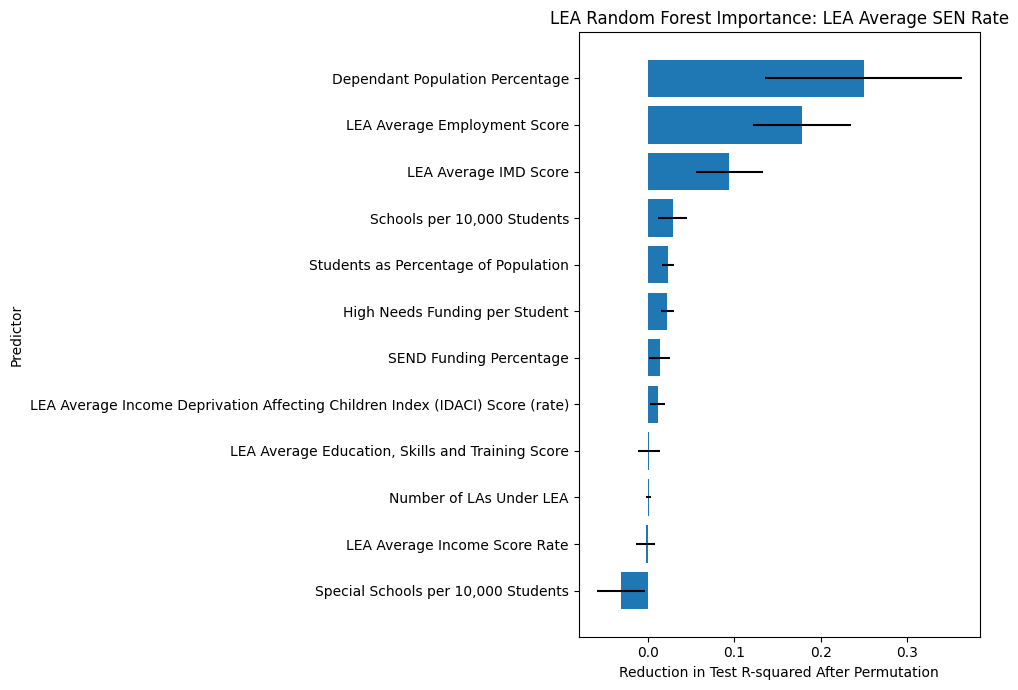

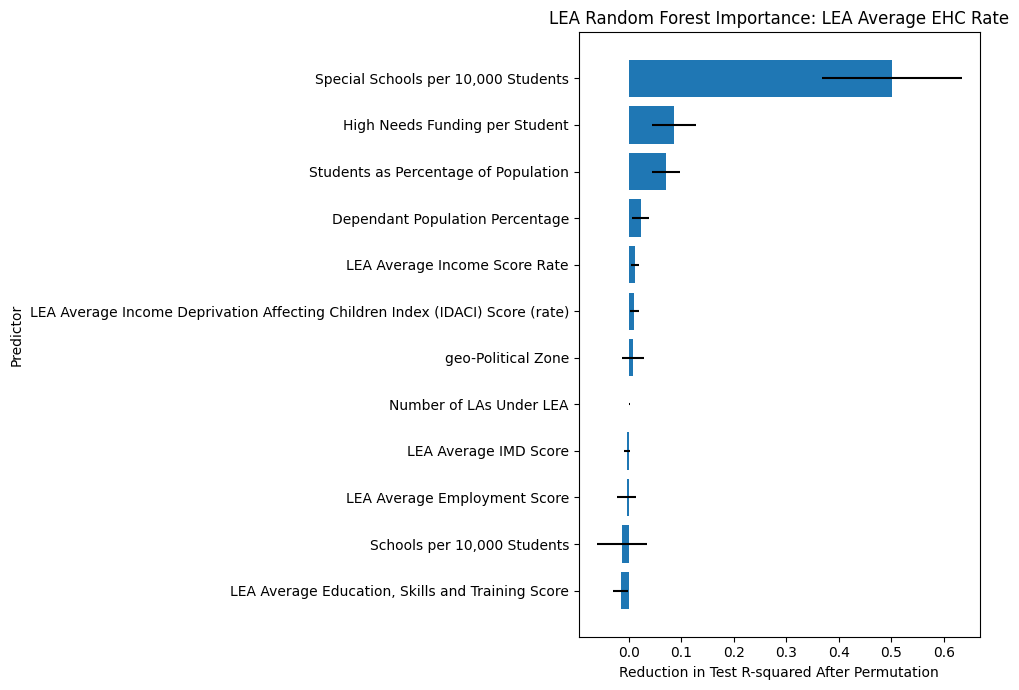

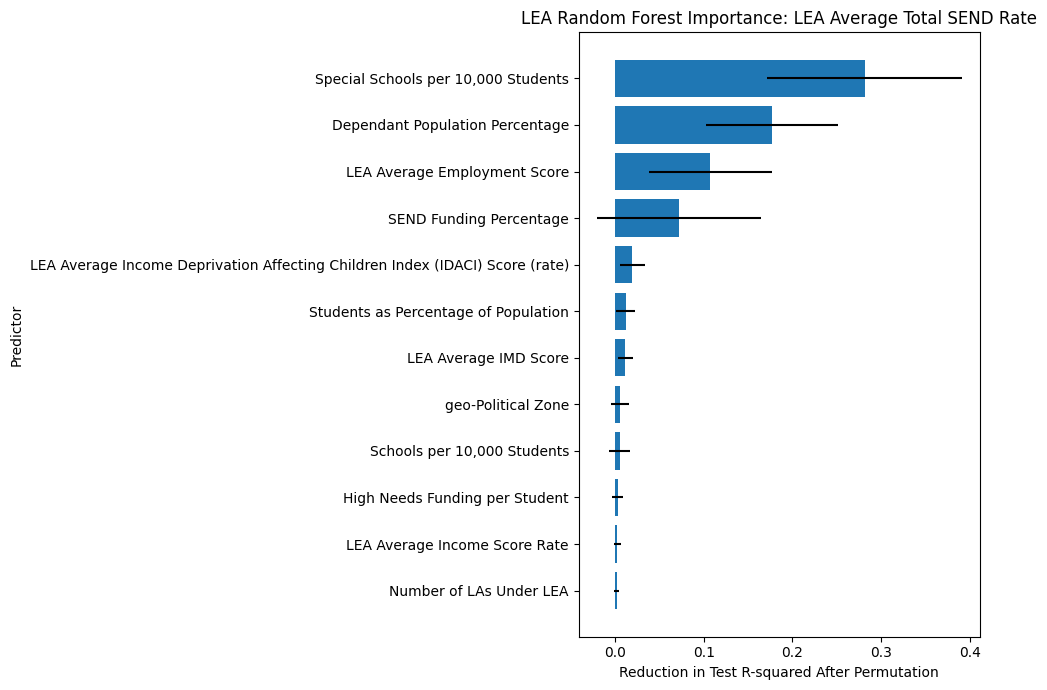

In [ ]:

#Display the predictors contributing most strongly to LEA Random
#Forest predictions.


for outcome, importance_table in (
    lea_random_forest_importance_tables.items()
):

    plot_table = (
        importance_table
        .head(12)
        .sort_values(
            "Mean Permutation Importance",
            ascending=True
        )
    )

    plt.figure(
        figsize=(10, 7)
    )

    plt.barh(
        plot_table["Predictor"],
        plot_table[
            "Mean Permutation Importance"
        ],
        xerr=plot_table[
            "Importance Standard Deviation"
        ]
    )

    plt.title(
        f"LEA Random Forest Importance: {outcome}"
    )

    plt.xlabel(
        "Reduction in Test R-squared After Permutation"
    )

    plt.ylabel(
        "Predictor"
    )

    plt.tight_layout()
    plt.show()

##SECTION 6.41 — COMPARE FUNDING ACROSS REGRESSION METHODS

In [ ]:

#Assess whether the two funding variables are consistently useful
#across:
#OLS;
#Ridge;
#Lasso;
#Random Forest.
#
#The models answer different questions:
#OLS tests adjusted statistical association;
#Ridge assesses stabilised linear contribution;
#Lasso assesses retained predictive value;
#Random Forest assesses nonlinear predictive importance.


lea_funding_method_rows = []

for outcome in LEA_REGRESSION_OUTCOMES:

    model_c_coefficients = (
        lea_ols_coefficient_tables[
            outcome
        ]["Model C"]
    )

    ridge_table = (
        lea_ridge_coefficient_tables[
            outcome
        ]
    )

    lasso_table = (
        lea_lasso_coefficient_tables[
            outcome
        ]
    )

    rf_table = (
        lea_random_forest_importance_tables[
            outcome
        ]
    )

    for original_name, safe_name in [
        (
            "High Needs Funding per Student",
            "high_needs_per_student"
        ),
        (
            "SEND Funding Percentage",
            "send_funding_pct"
        )
    ]:

        ols_row = model_c_coefficients[
            model_c_coefficients[
                "Term"
            ] == safe_name
        ]

        ridge_row = ridge_table[
            ridge_table[
                "Feature"
            ] == original_name
        ]

        lasso_row = lasso_table[
            lasso_table[
                "Feature"
            ] == original_name
        ]

        rf_row = rf_table[
            rf_table[
                "Predictor"
            ] == original_name
        ]

        lea_funding_method_rows.append({
            "Outcome":
                outcome,

            "Funding Predictor":
                original_name,

            "OLS Coefficient":
                (
                    ols_row[
                        "Coefficient"
                    ].iloc[0]
                    if len(ols_row) > 0
                    else np.nan
                ),

            "OLS p-value":
                (
                    ols_row[
                        "p-value"
                    ].iloc[0]
                    if len(ols_row) > 0
                    else np.nan
                ),

            "Ridge Coefficient":
                (
                    ridge_row[
                        "Coefficient"
                    ].iloc[0]
                    if len(ridge_row) > 0
                    else np.nan
                ),

            "Lasso Retained":
                (
                    bool(
                        lasso_row[
                            "Retained by Lasso"
                        ].iloc[0]
                    )
                    if len(lasso_row) > 0
                    else False
                ),

            "Random Forest Importance":
                (
                    rf_row[
                        "Mean Permutation Importance"
                    ].iloc[0]
                    if len(rf_row) > 0
                    else np.nan
                )
        })

lea_funding_method_table = pd.DataFrame(
    lea_funding_method_rows
)

display(
    lea_funding_method_table.round(6)
)

,Outcome,Funding Predictor,OLS Coefficient,OLS p-value,Ridge Coefficient,Lasso Retained,Random Forest Importance
0,LEA Average SEN Rate,High Needs Funding per Student,0.0000,0.3343,0.0007,True,0.0225
1,LEA Average SEN Rate,SEND Funding Percentage,0.1062,0.0689,0.0018,True,0.0133
2,LEA Average EHC Rate,High Needs Funding per Student,-0.0000,0.0990,-0.0062,True,0.0867
3,LEA Average EHC Rate,SEND Funding Percentage,0.1360,0.3057,0.0060,True,-0.0532
4,LEA Average Total SEND Rate,High Needs Funding per Student,-0.0000,0.1878,-0.0031,True,0.0030
5,LEA Average Total SEND Rate,SEND Funding Percentage,0.2422,0.0486,0.0075,True,0.0722


##SECTION 6.42 — CREATE LEA TEST PREDICTION TABLES

In [ ]:

#Save observed outcomes, predictions and residuals for all four
#modelling approaches.

#These tables support model inspection and later comparison with
#the LA results.


lea_prediction_tables = {}

for outcome in LEA_REGRESSION_OUTCOMES:

    split = (
        lea_train_test_splits[
            outcome
        ]
    )

    prediction_table = (
        lea_regression.loc[
            split["X_test"].index,
            [
                (
                    "LEA "
                    "(Local Education Authority)"
                ),
                outcome
            ]
        ]
        .copy()
    )

    prediction_table.rename(
        columns={
            outcome:
                "Actual Outcome"
        },
        inplace=True
    )

    for model_name, fitted_model in (
        fitted_lea_ml_models[
            outcome
        ].items()
    ):

        safe_model_name = (
            model_name.replace(
                " ",
                "_"
            )
        )

        prediction = fitted_model.predict(
            split["X_test"]
        )

        prediction_table[
            f"{safe_model_name}_Prediction"
        ] = prediction

        prediction_table[
            f"{safe_model_name}_Residual"
        ] = (
            prediction_table[
                "Actual Outcome"
            ]
            -
            prediction
        )

    lea_prediction_tables[
        outcome
    ] = prediction_table

    display(
        prediction_table.head()
    )

,LEA (Local Education Authority),Actual Outcome,Linear_Regression_Prediction,Linear_Regression_Residual,Ridge_Regression_Prediction,Ridge_Regression_Residual,Lasso_Regression_Prediction,Lasso_Regression_Residual,Random_Forest_Prediction,Random_Forest_Residual
76,Merton,0.1435,0.1358,0.0077,0.1372,0.0064,0.1380,0.0055,0.1412,0.0023
18,Bury,0.1437,0.1438,-0.0001,0.1443,-0.0006,0.1440,-0.0003,0.1450,-0.0013
82,North East Lincolnshire,0.1428,0.1498,-0.0071,0.1505,-0.0077,0.1521,-0.0093,0.1563,-0.0136
81,Norfolk,0.1486,0.1564,-0.0079,0.1552,-0.0067,0.1563,-0.0077,0.1553,-0.0067
143,Wigan,0.1555,0.1474,0.0080,0.1477,0.0078,0.1484,0.0071,0.1457,0.0097


,LEA (Local Education Authority),Actual Outcome,Linear_Regression_Prediction,Linear_Regression_Residual,Ridge_Regression_Prediction,Ridge_Regression_Residual,Lasso_Regression_Prediction,Lasso_Regression_Residual,Random_Forest_Prediction,Random_Forest_Residual
76,Merton,0.1144,0.1261,-0.0117,0.1186,-0.0042,0.1214,-0.0070,0.1328,-0.0184
18,Bury,0.1121,0.1295,-0.0174,0.1285,-0.0165,0.1289,-0.0168,0.1225,-0.0104
82,North East Lincolnshire,0.1142,0.1161,-0.0019,0.1141,0.0001,0.1149,-0.0007,0.1140,0.0002
81,Norfolk,0.1298,0.1241,0.0057,0.1173,0.0125,0.1166,0.0132,0.1157,0.0141
143,Wigan,0.1215,0.1260,-0.0044,0.1212,0.0004,0.1226,-0.0010,0.1011,0.0204


,LEA (Local Education Authority),Actual Outcome,Linear_Regression_Prediction,Linear_Regression_Residual,Ridge_Regression_Prediction,Ridge_Regression_Residual,Lasso_Regression_Prediction,Lasso_Regression_Residual,Random_Forest_Prediction,Random_Forest_Residual
76,Merton,0.2579,0.2619,-0.0040,0.2607,-0.0028,0.2595,-0.0016,0.2828,-0.0248
18,Bury,0.2558,0.2733,-0.0176,0.2733,-0.0175,0.2730,-0.0172,0.2638,-0.0080
82,North East Lincolnshire,0.2570,0.2660,-0.0090,0.2658,-0.0088,0.2654,-0.0085,0.2671,-0.0101
81,Norfolk,0.2783,0.2805,-0.0022,0.2788,-0.0005,0.2767,0.0016,0.2692,0.0091
143,Wigan,0.2770,0.2734,0.0036,0.2725,0.0045,0.2717,0.0054,0.2493,0.0277


##SECTION 6.43 — PRINT LEA MODEL SUMMARIES

In [ ]:

#Present:
#Model C OLS explanatory performance;
#preferred predictive model;
#funding joint-test result;
#leading Random Forest predictor.


print("=" * 90)
print("SECTION 6: LEA REGRESSION SUMMARY")
print("=" * 90)

for outcome in LEA_REGRESSION_OUTCOMES:

    ols_row = (
        lea_ols_comparison_table[
            (
                lea_ols_comparison_table[
                    "Outcome"
                ] == outcome
            )
            &
            (
                lea_ols_comparison_table[
                    "Model"
                ] == "Model C"
            )
        ]
        .iloc[0]
    )

    preferred_row = (
        preferred_lea_models_table[
            preferred_lea_models_table[
                "Outcome"
            ] == outcome
        ]
        .iloc[0]
    )

    funding_joint_row = (
        lea_funding_joint_test_table[
            lea_funding_joint_test_table[
                "Outcome"
            ] == outcome
        ]
        .iloc[0]
    )

    top_rf_predictor = (
        lea_random_forest_importance_tables[
            outcome
        ]
        .iloc[0]
    )

    print("\n" + "-" * 90)
    print(outcome)

    print(
        "Model C OLS R-squared:",
        round(
            ols_row[
                "R-squared"
            ],
            4
        )
    )

    print(
        "Model C adjusted R-squared:",
        round(
            ols_row[
                "Adjusted R-squared"
            ],
            4
        )
    )

    print(
        "Preferred predictive model:",
        preferred_row[
            "Model"
        ]
    )

    print(
        "Mean CV R-squared:",
        round(
            preferred_row[
                "Mean CV R-squared"
            ],
            4
        )
    )

    print(
        "Funding joint-test p-value:",
        round(
            funding_joint_row[
                "p-value"
            ],
            4
        )
    )

    print(
        "Funding joint-test conclusion:",
        funding_joint_row[
            "Interpretation"
        ]
    )

    print(
        "Top Random Forest predictor:",
        top_rf_predictor[
            "Predictor"
        ]
    )

SECTION 6: LEA REGRESSION SUMMARY

------------------------------------------------------------------------------------------
LEA Average SEN Rate
Model C OLS R-squared: 0.506
Model C adjusted R-squared: 0.43
Preferred predictive model: Lasso Regression
Mean CV R-squared: 0.3068
Funding joint-test p-value: 0.1216
Funding joint-test conclusion: Funding variables are not jointly significant
Top Random Forest predictor: Dependant Population Percentage

------------------------------------------------------------------------------------------
LEA Average EHC Rate
Model C OLS R-squared: 0.4413
Model C adjusted R-squared: 0.3554
Preferred predictive model: Random Forest
Mean CV R-squared: 0.2582
Funding joint-test p-value: 0.1785
Funding joint-test conclusion: Funding variables are not jointly significant
Top Random Forest predictor: Special Schools per 10,000 Students

------------------------------------------------------------------------------------------
LEA Average Total SEND Rate
Mode

##SECTION 6.44 — CREATE THE LEA REGRESSION OUTPUT FOLDER

In [ ]:

#Store all Section 6 results under the corrected Final Main 3
#directory.


LEA_REGRESSION_OUTPUT_FOLDER = (
    "/content/drive/MyDrive/MSC Dissertation/"
    "Final Main 3/Analysis Outputs/"
    "LEA Regression"
)

os.makedirs(
    LEA_REGRESSION_OUTPUT_FOLDER,
    exist_ok=True
)

LEA_REGRESSION_RESULTS_PATH = os.path.join(
    LEA_REGRESSION_OUTPUT_FOLDER,
    "LEA_Regression_Results.xlsx"
)

print(
    "LEA regression output folder:"
)

print(
    LEA_REGRESSION_OUTPUT_FOLDER
)

LEA regression output folder:
/content/drive/MyDrive/MSC Dissertation/Final Main 3/Analysis Outputs/LEA Regression


##SECTION 6.45 — EXPORT LEA REGRESSION RESULTS

In [ ]:

#Save:
#OLS comparisons;
#coefficient tables;
#funding results;
#tuning results;
#model comparisons;
#predictor importance;
#test predictions.


with pd.ExcelWriter(
    LEA_REGRESSION_RESULTS_PATH,
    engine="openpyxl"
) as writer:

    lea_ols_comparison_table.to_excel(
        writer,
        sheet_name="OLS Model Comparison",
        index=False
    )

    lea_funding_joint_test_table.to_excel(
        writer,
        sheet_name="Funding Joint Tests",
        index=False
    )

    lea_ridge_tuning_table.to_excel(
        writer,
        sheet_name="Ridge Tuning",
        index=False
    )

    lea_lasso_tuning_table.to_excel(
        writer,
        sheet_name="Lasso Tuning",
        index=False
    )

    lea_rf_tuning_table.to_excel(
        writer,
        sheet_name="RF Tuning",
        index=False
    )

    lea_final_model_comparison.to_excel(
        writer,
        sheet_name="Final Model Comparison",
        index=False
    )

    preferred_lea_models_table.to_excel(
        writer,
        sheet_name="Preferred Models",
        index=False
    )

    lea_funding_method_table.to_excel(
        writer,
        sheet_name="Funding Method Comparison",
        index=False
    )

    for outcome in LEA_REGRESSION_OUTCOMES:

        short_outcome = (
            outcome
            .replace(
                "LEA Average ",
                ""
            )
            .replace(
                " Rate",
                ""
            )
            .replace(
                "Total SEND",
                "Total"
            )
        )

        for model_name in [
            "Model A",
            "Model B",
            "Model C"
        ]:

            lea_ols_coefficient_tables[
                outcome
            ][model_name].to_excel(
                writer,
                sheet_name=(
                    f"{model_name} {short_outcome}"
                )[:31],
                index=False
            )

        lea_ridge_coefficient_tables[
            outcome
        ].to_excel(
            writer,
            sheet_name=(
                f"Ridge {short_outcome}"
            )[:31],
            index=False
        )

        lea_lasso_coefficient_tables[
            outcome
        ].to_excel(
            writer,
            sheet_name=(
                f"Lasso {short_outcome}"
            )[:31],
            index=False
        )

        lea_random_forest_importance_tables[
            outcome
        ].to_excel(
            writer,
            sheet_name=(
                f"RF Importance {short_outcome}"
            )[:31],
            index=False
        )

        lea_prediction_tables[
            outcome
        ].to_excel(
            writer,
            sheet_name=(
                f"Predictions {short_outcome}"
            )[:31],
            index=False
        )

print(
    "LEA regression results saved:"
)

print(
    LEA_REGRESSION_RESULTS_PATH
)

LEA regression results saved:
/content/drive/MyDrive/MSC Dissertation/Final Main 3/Analysis Outputs/LEA Regression/LEA_Regression_Results.xlsx


##SECTION 6.46 — SAVE THE PREPARED LEA DATASET

In [ ]:

#Save the final LEA dataset containing the newly created funding,
#population and school-provision measures.
#
#This file provides a reproducible starting point for future LEA
#diagnostics or comparative analysis.


PREPARED_LEA_OUTPUT_FOLDER = (
    "/content/drive/MyDrive/MSC Dissertation/"
    "Final Main 3/Prepared Data"
)

os.makedirs(
    PREPARED_LEA_OUTPUT_FOLDER,
    exist_ok=True
)

PREPARED_LEA_OUTPUT_PATH = os.path.join(
    PREPARED_LEA_OUTPUT_FOLDER,
    "Prepared_LEA_Data.xlsx"
)

lea_regression.to_excel(
    PREPARED_LEA_OUTPUT_PATH,
    index=False
)

print(
    "Prepared LEA dataset saved:"
)

print(
    PREPARED_LEA_OUTPUT_PATH
)

Prepared LEA dataset saved:
/content/drive/MyDrive/MSC Dissertation/Final Main 3/Prepared Data/Prepared_LEA_Data.xlsx
